# Multi-Asset Monte Carlo Portfolio Optimizer and Risk Surface Lab

This project builds a quantitative portfolio-allocation and risk-simulation
system using a diversified universe of stock, bond, commodity, real-estate,
and Treasury ETFs.

The system:

- Downloads and validates historical market data
- Estimates return, volatility, and correlation relationships
- Simulates thousands of candidate portfolios
- Identifies maximum-Sharpe and minimum-volatility allocations
- Runs correlated Monte Carlo simulations of future portfolio values
- Compares parametric and historical-bootstrap simulation methods
- Measures drawdown, Value at Risk, Expected Shortfall, and loss probability
- Produces professional two-dimensional and three-dimensional risk
  visualizations
- Tests portfolio behavior under adverse market scenarios

## Research question

How do portfolio allocation, investment horizon, market correlation, and
simulation assumptions affect expected growth and downside risk?

## Important note

Monte Carlo simulation does not predict the future. It generates possible
outcomes based on historical data and explicit statistical assumptions. Results
are educational and do not constitute investment advice.

In [1]:
# ============================================================
# CELL 1: INSTALL REQUIRED PACKAGES
# ============================================================

%pip install -q yfinance pandas-datareader

In [2]:
# ============================================================
# CELL 2: IMPORTS AND NOTEBOOK SETTINGS
# ============================================================

from __future__ import annotations

import math
import warnings
from dataclasses import dataclass
from typing import Final

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

from matplotlib import cm
from matplotlib.ticker import PercentFormatter
from pandas_datareader import data as pdr
from scipy.optimize import minimize
from scipy.stats import norm


warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

RANDOM_SEED: Final[int] = 42

np.random.seed(RANDOM_SEED)

print("Environment loaded successfully.")
print(f"NumPy version:  {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Environment loaded successfully.
NumPy version:  2.0.2
Pandas version: 2.2.2


## 1. Project Configuration and Asset Universe

The project uses liquid ETFs representing several major asset classes. This
provides a more realistic portfolio-allocation problem than selecting several
highly similar technology stocks.

Historical data before the official analysis period is downloaded to support
rolling calculations and model validation.

In [3]:
# ============================================================
# CELL 3: PROJECT CONFIGURATION
# ============================================================

@dataclass(frozen=True)
class ProjectConfig:
    """Central configuration for the Monte Carlo research project."""

    data_start: str = "2010-01-01"
    analysis_start: str = "2012-01-01"
    analysis_end: str = "2025-12-31"

    initial_capital: float = 100_000.0

    trading_days_per_year: int = 252
    months_per_year: int = 12

    random_portfolios: int = 50_000
    monte_carlo_paths: int = 10_000
    simulation_years: int = 10

    transaction_cost_bps: float = 5.0

    maximum_asset_weight: float = 0.35
    minimum_asset_weight: float = 0.00

    confidence_level: float = 0.95


CONFIG = ProjectConfig()


ASSET_UNIVERSE = {
    "SPY": "U.S. Large-Cap Equity",
    "QQQ": "Nasdaq-100 Equity",
    "IWM": "U.S. Small-Cap Equity",
    "EFA": "Developed International Equity",
    "EEM": "Emerging-Market Equity",
    "TLT": "Long-Term U.S. Treasuries",
    "LQD": "Investment-Grade Corporate Bonds",
    "GLD": "Gold",
    "VNQ": "U.S. Real Estate",
    "BIL": "Short-Term Treasury Bills",
}


TICKERS = list(ASSET_UNIVERSE.keys())


print("Project configuration loaded.")
print(f"Assets:              {len(TICKERS)}")
print(f"Random portfolios:   {CONFIG.random_portfolios:,}")
print(f"Monte Carlo paths:   {CONFIG.monte_carlo_paths:,}")
print(f"Simulation horizon:  {CONFIG.simulation_years} years")
print(f"Initial capital:     ${CONFIG.initial_capital:,.2f}")

display(
    pd.Series(
        ASSET_UNIVERSE,
        name="Asset Class",
    ).to_frame()
)

Project configuration loaded.
Assets:              10
Random portfolios:   50,000
Monte Carlo paths:   10,000
Simulation horizon:  10 years
Initial capital:     $100,000.00


,Asset Class
SPY,U.S. Large-Cap Equity
QQQ,Nasdaq-100 Equity
IWM,U.S. Small-Cap Equity
EFA,Developed International Equity
EEM,Emerging-Market Equity
TLT,Long-Term U.S. Treasuries
LQD,Investment-Grade Corporate Bonds
GLD,Gold
VNQ,U.S. Real Estate
BIL,Short-Term Treasury Bills


## 2. Market Data Collection and Validation

Adjusted closing prices are downloaded for all ETFs in the research universe.

Adjusted prices account for distributions and stock splits, making them
appropriate for historical total-return calculations.

Before any portfolio model is built, the data is checked for:

- Missing assets
- Duplicate dates
- Nonpositive prices
- Incomplete observations
- Unusually large daily returns
- Inconsistent date ranges

In [4]:
# ============================================================
# CELL 4: DOWNLOAD ADJUSTED ETF PRICES
# ============================================================

DOWNLOAD_END = (
    pd.Timestamp(CONFIG.analysis_end)
    + pd.Timedelta(days=1)
).strftime("%Y-%m-%d")


def extract_close_price_panel(
    market_data: pd.DataFrame,
    tickers: list[str],
) -> pd.DataFrame:
    """
    Extract a clean Close-price matrix from a yfinance download.

    The helper handles both ordinary columns and MultiIndex columns.
    """

    if market_data is None or market_data.empty:
        raise RuntimeError(
            "The market-data download returned no observations."
        )

    if isinstance(market_data.columns, pd.MultiIndex):

        level_zero = (
            market_data.columns
            .get_level_values(0)
            .astype(str)
        )

        level_one = (
            market_data.columns
            .get_level_values(1)
            .astype(str)
        )

        if "Close" in level_zero:
            close_prices = market_data["Close"].copy()

        elif "Close" in level_one:
            close_prices = market_data.xs(
                "Close",
                axis=1,
                level=1,
            ).copy()

        else:
            raise KeyError(
                "A Close field was not found in the downloaded data."
            )

    else:
        if "Close" not in market_data.columns:
            raise KeyError(
                "A Close field was not found in the downloaded data."
            )

        close_prices = market_data[["Close"]].copy()

        if len(tickers) == 1:
            close_prices.columns = tickers

    close_prices.columns = [
        str(column).upper()
        for column in close_prices.columns
    ]

    return close_prices


raw_market_data = yf.download(
    tickers=TICKERS,
    start=CONFIG.data_start,
    end=DOWNLOAD_END,
    auto_adjust=True,
    actions=False,
    repair=True,
    progress=False,
    threads=True,
    group_by="column",
    timeout=30,
    multi_level_index=True,
)


adjusted_close_prices = extract_close_price_panel(
    market_data=raw_market_data,
    tickers=TICKERS,
)


adjusted_close_prices.index = pd.DatetimeIndex(
    adjusted_close_prices.index
).tz_localize(None)


adjusted_close_prices = (
    adjusted_close_prices
    .sort_index()
    .loc[
        ~adjusted_close_prices.index.duplicated(
            keep="first"
        )
    ]
    .reindex(columns=TICKERS)
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
    .dropna(how="all")
)


# Fill only very short isolated gaps.
adjusted_close_prices = (
    adjusted_close_prices.ffill(limit=2)
)


print("Adjusted ETF prices downloaded successfully.")
print(
    f"First observation: "
    f"{adjusted_close_prices.index.min().date()}"
)
print(
    f"Last observation:  "
    f"{adjusted_close_prices.index.max().date()}"
)
print(
    f"Trading days:      "
    f"{len(adjusted_close_prices):,}"
)
print(
    f"Assets downloaded: "
    f"{adjusted_close_prices.shape[1]}"
)

display(adjusted_close_prices.tail())

Adjusted ETF prices downloaded successfully.
First observation: 2010-01-04
Last observation:  2025-12-31
Trading days:      4,024
Assets downloaded: 10


,SPY,QQQ,IWM,EFA,EEM,TLT,LQD,GLD,VNQ,BIL
Date,,,,,,,,,,
2025-12-24,686.7305,622.4603,251.6628,94.9081,54.1386,86.3960,108.5753,411.9300,87.0539,90.0221
2025-12-26,686.6609,622.4203,250.3781,95.0656,54.5166,86.1114,108.5655,416.7400,87.1520,90.0516
2025-12-29,684.2139,619.4074,248.8445,94.7802,54.3774,86.4352,108.7127,398.6000,87.3285,90.0516
2025-12-30,683.3783,617.9708,247.0022,94.9377,54.5962,86.2291,108.5851,398.8900,87.5051,90.0615
2025-12-31,678.3152,612.8629,245.1399,94.5340,54.4271,85.5421,108.1239,396.3100,86.7891,90.0713


In [5]:
# ============================================================
# CELL 5: MARKET-DATA VALIDATION
# ============================================================

missing_asset_tickers = [
    ticker
    for ticker in TICKERS
    if (
        ticker not in adjusted_close_prices.columns
        or adjusted_close_prices[ticker].dropna().empty
    )
]


if missing_asset_tickers:
    raise RuntimeError(
        "No valid price history was downloaded for: "
        + ", ".join(missing_asset_tickers)
    )


assert adjusted_close_prices.index.is_monotonic_increasing, (
    "Price dates are not sorted."
)

assert adjusted_close_prices.index.is_unique, (
    "Duplicate price dates were found."
)

assert (
    adjusted_close_prices.dropna() > 0
).all().all(), "Nonpositive ETF prices were found."


price_coverage_report = pd.DataFrame(
    {
        "First Valid Date": adjusted_close_prices.apply(
            lambda series: series.first_valid_index()
        ),
        "Last Valid Date": adjusted_close_prices.apply(
            lambda series: series.last_valid_index()
        ),
        "Valid Observations": adjusted_close_prices.notna().sum(),
        "Missing Observations": adjusted_close_prices.isna().sum(),
        "Coverage": adjusted_close_prices.notna().mean(),
    }
)


low_coverage_assets = price_coverage_report[
    "Coverage"
] < 0.98


if not low_coverage_assets.empty:
    print(
        "Warning: the following assets have less than "
        "98% data coverage:"
    )

    display(low_coverage_assets)


preliminary_returns = (
    adjusted_close_prices
    .pct_change(fill_method=None)
)


extreme_return_events = (
    preliminary_returns
    .abs()
    .stack()
    .sort_values(ascending=False)
    .rename("Absolute Daily Return")
    .to_frame()
)


extreme_return_events.index.names = [
    "Date",
    "Ticker",
]


print("Market-data validation completed.")
print(
    f"Duplicate dates: "
    f"{adjusted_close_prices.index.duplicated().sum()}"
)

print(
    f"Nonpositive prices: "
    f"{int((adjusted_close_prices <= 0).sum().sum())}"
)

print()
print("ETF coverage report:")

display(price_coverage_report)

print()
print("Ten largest absolute daily returns for inspection:")

display(extreme_return_events.head(10))

,Coverage
SPY,False
QQQ,False
IWM,False
EFA,False
EEM,False
TLT,False
LQD,False
GLD,False
VNQ,False
BIL,False


Market-data validation completed.
Duplicate dates: 0
Nonpositive prices: 0

ETF coverage report:


,First Valid Date,Last Valid Date,Valid Observations,Missing Observations,Coverage
SPY,2010-01-04,2025-12-31,4024,0,1.0000
QQQ,2010-01-04,2025-12-31,4024,0,1.0000
IWM,2010-01-04,2025-12-31,4024,0,1.0000
EFA,2010-01-04,2025-12-31,4024,0,1.0000
EEM,2010-01-04,2025-12-31,4024,0,1.0000
TLT,2010-01-04,2025-12-31,4024,0,1.0000
LQD,2010-01-04,2025-12-31,4024,0,1.0000
GLD,2010-01-04,2025-12-31,4024,0,1.0000
VNQ,2010-01-04,2025-12-31,4024,0,1.0000
BIL,2010-01-04,2025-12-31,4024,0,1.0000



Ten largest absolute daily returns for inspection:


Absolute Daily Return
Date       Ticker                       
2020-03-16 VNQ                    0.1773
           IWM                    0.1327
           EEM                    0.1248
2025-04-09 QQQ                    0.1200
2020-03-16 QQQ                    0.1198
2020-03-12 IWM                    0.1105
           EFA                    0.1099
2020-03-16 SPY                    0.1094
2025-04-09 SPY                    0.1050
2020-03-16 EFA                    0.1032

In [6]:
# ============================================================
# CELL 6: CREATE ANALYSIS PRICE AND RETURN MATRICES
# ============================================================

analysis_prices = (
    adjusted_close_prices
    .loc[
        CONFIG.analysis_start:
        CONFIG.analysis_end
    ]
    .copy()
)


daily_asset_returns = (
    analysis_prices
    .pct_change(fill_method=None)
    .dropna(how="all")
)


# Require complete cross-sectional observations for the
# portfolio covariance and simulation models.
complete_daily_returns = (
    daily_asset_returns
    .dropna(how="any")
    .copy()
)


if complete_daily_returns.empty:
    raise RuntimeError(
        "No complete daily return observations are available."
    )


assert complete_daily_returns.notna().all().all()
assert np.isfinite(complete_daily_returns).all().all()


print("Official analysis dataset created.")
print(
    f"Analysis start: "
    f"{complete_daily_returns.index.min().date()}"
)
print(
    f"Analysis end:   "
    f"{complete_daily_returns.index.max().date()}"
)
print(
    f"Complete daily observations: "
    f"{len(complete_daily_returns):,}"
)
print(
    f"Assets: "
    f"{complete_daily_returns.shape[1]}"
)

display(complete_daily_returns.tail())

Official analysis dataset created.
Analysis start: 2012-01-04
Analysis end:   2025-12-31
Complete daily observations: 3,519
Assets: 10


,SPY,QQQ,IWM,EFA,EEM,TLT,LQD,GLD,VNQ,BIL
Date,,,,,,,,,,
2025-12-24,0.0035,0.0029,0.0025,0.0012,0.0020,0.0061,0.0039,-0.0041,0.0066,0.0003
2025-12-26,-0.0001,-0.0001,-0.0051,0.0017,0.0070,-0.0033,-0.0001,0.0117,0.0011,0.0003
2025-12-29,-0.0036,-0.0048,-0.0061,-0.0030,-0.0026,0.0038,0.0014,-0.0435,0.0020,0.0000
2025-12-30,-0.0012,-0.0023,-0.0074,0.0017,0.0040,-0.0024,-0.0012,0.0007,0.0020,0.0001
2025-12-31,-0.0074,-0.0083,-0.0075,-0.0043,-0.0031,-0.0080,-0.0042,-0.0065,-0.0082,0.0001


### Risk-Free Rate

The three-month U.S. Treasury yield is used as an approximation of the
risk-free rate.

The annualized Treasury yield is converted into an equivalent daily rate and
aligned with the ETF return dates. This allows excess-return and Sharpe-ratio
calculations to use a changing interest rate rather than assuming that the
risk-free rate is always zero.

In [7]:
# ============================================================
# CELL 7: DOWNLOAD AND ALIGN THE RISK-FREE RATE
# ============================================================

FRED_RISK_FREE_SERIES = "DGS3MO"


risk_free_yield = pdr.DataReader(
    FRED_RISK_FREE_SERIES,
    "fred",
    start=CONFIG.data_start,
    end=CONFIG.analysis_end,
)


risk_free_yield.index = pd.DatetimeIndex(
    risk_free_yield.index
).tz_localize(None)


risk_free_yield = (
    risk_free_yield
    .rename(
        columns={
            FRED_RISK_FREE_SERIES:
            "Annualized Treasury Yield"
        }
    )
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
    .ffill()
)


aligned_annual_risk_free_yield = (
    risk_free_yield[
        "Annualized Treasury Yield"
    ]
    .reindex(complete_daily_returns.index)
    .ffill()
    .bfill()
)


# FRED reports the yield in percentage points.
annual_risk_free_decimal = (
    aligned_annual_risk_free_yield / 100.0
)


daily_risk_free_rate = (
    (1.0 + annual_risk_free_decimal)
    ** (
        1.0
        / CONFIG.trading_days_per_year
    )
    - 1.0
)


daily_risk_free_rate.name = (
    "Daily Risk-Free Rate"
)


assert daily_risk_free_rate.notna().all()
assert np.isfinite(daily_risk_free_rate).all()


print("Risk-free-rate data loaded successfully.")

print(
    "Average annualized Treasury yield: "
    f"{annual_risk_free_decimal.mean():.2%}"
)

print(
    "Latest annualized Treasury yield in dataset: "
    f"{annual_risk_free_decimal.iloc[-1]:.2%}"
)

display(
    pd.concat(
        [
            aligned_annual_risk_free_yield,
            daily_risk_free_rate,
        ],
        axis=1,
    ).tail()
)

Risk-free-rate data loaded successfully.
Average annualized Treasury yield: 1.62%
Latest annualized Treasury yield in dataset: 3.67%


,Annualized Treasury Yield,Daily Risk-Free Rate
Date,,
2025-12-24,3.6900,0.0001
2025-12-26,3.6400,0.0001
2025-12-29,3.6800,0.0001
2025-12-30,3.6500,0.0001
2025-12-31,3.6700,0.0001


In [8]:
# ============================================================
# CELL 8: INDIVIDUAL ASSET PERFORMANCE STATISTICS
# ============================================================

ANNUALIZATION_FACTOR = (
    CONFIG.trading_days_per_year
)


annualized_mean_returns = (
    complete_daily_returns.mean()
    * ANNUALIZATION_FACTOR
)


annualized_volatility = (
    complete_daily_returns.std(ddof=1)
    * np.sqrt(ANNUALIZATION_FACTOR)
)


annualized_covariance_matrix = (
    complete_daily_returns.cov()
    * ANNUALIZATION_FACTOR
)


correlation_matrix = (
    complete_daily_returns.corr()
)


annualized_risk_free_rate = (
    (
        1.0
        + daily_risk_free_rate.mean()
    )
    ** ANNUALIZATION_FACTOR
    - 1.0
)


individual_asset_sharpe = (
    annualized_mean_returns
    - annualized_risk_free_rate
) / annualized_volatility


elapsed_years = (
    (
        analysis_prices.index[-1]
        - analysis_prices.index[0]
    ).days
    / 365.25
)


asset_cagr = (
    analysis_prices.iloc[-1]
    / analysis_prices.iloc[0]
) ** (
    1.0 / elapsed_years
) - 1.0


asset_statistics = pd.DataFrame(
    {
        "Asset Class": pd.Series(
            ASSET_UNIVERSE
        ),
        "CAGR": asset_cagr,
        "Arithmetic Annual Return": annualized_mean_returns,
        "Annualized Volatility": annualized_volatility,
        "Sharpe Ratio": individual_asset_sharpe,
    }
)


asset_statistics = (
    asset_statistics
    .sort_values(
        "Sharpe Ratio",
        ascending=False,
    )
)


print("Individual asset statistics calculated.")

display(
    asset_statistics.style.format(
        {
            "CAGR": "{:.2%}",
            "Arithmetic Annual Return": "{:.2%}",
            "Annualized Volatility": "{:.2%}",
            "Sharpe Ratio": "{:.3f}",
        }
    )
)

Individual asset statistics calculated.


,Asset Class,CAGR,Arithmetic Annual Return,Annualized Volatility,Sharpe Ratio
QQQ,Nasdaq-100 Equity,19.57%,20.02%,20.50%,0.898
SPY,U.S. Large-Cap Equity,14.74%,15.17%,16.67%,0.814
IWM,U.S. Small-Cap Equity,10.37%,12.15%,21.25%,0.496
EFA,Developed International Equity,7.84%,8.97%,16.70%,0.441
GLD,Gold,6.89%,7.86%,15.37%,0.407
VNQ,U.S. Real Estate,7.16%,8.79%,19.21%,0.374
EEM,Emerging-Market Equity,4.70%,6.60%,19.92%,0.251
LQD,Investment-Grade Corporate Bonds,3.17%,3.43%,7.83%,0.234
TLT,Long-Term U.S. Treasuries,0.37%,1.43%,14.57%,-0.012
BIL,Short-Term Treasury Bills,1.38%,1.38%,0.30%,-0.764


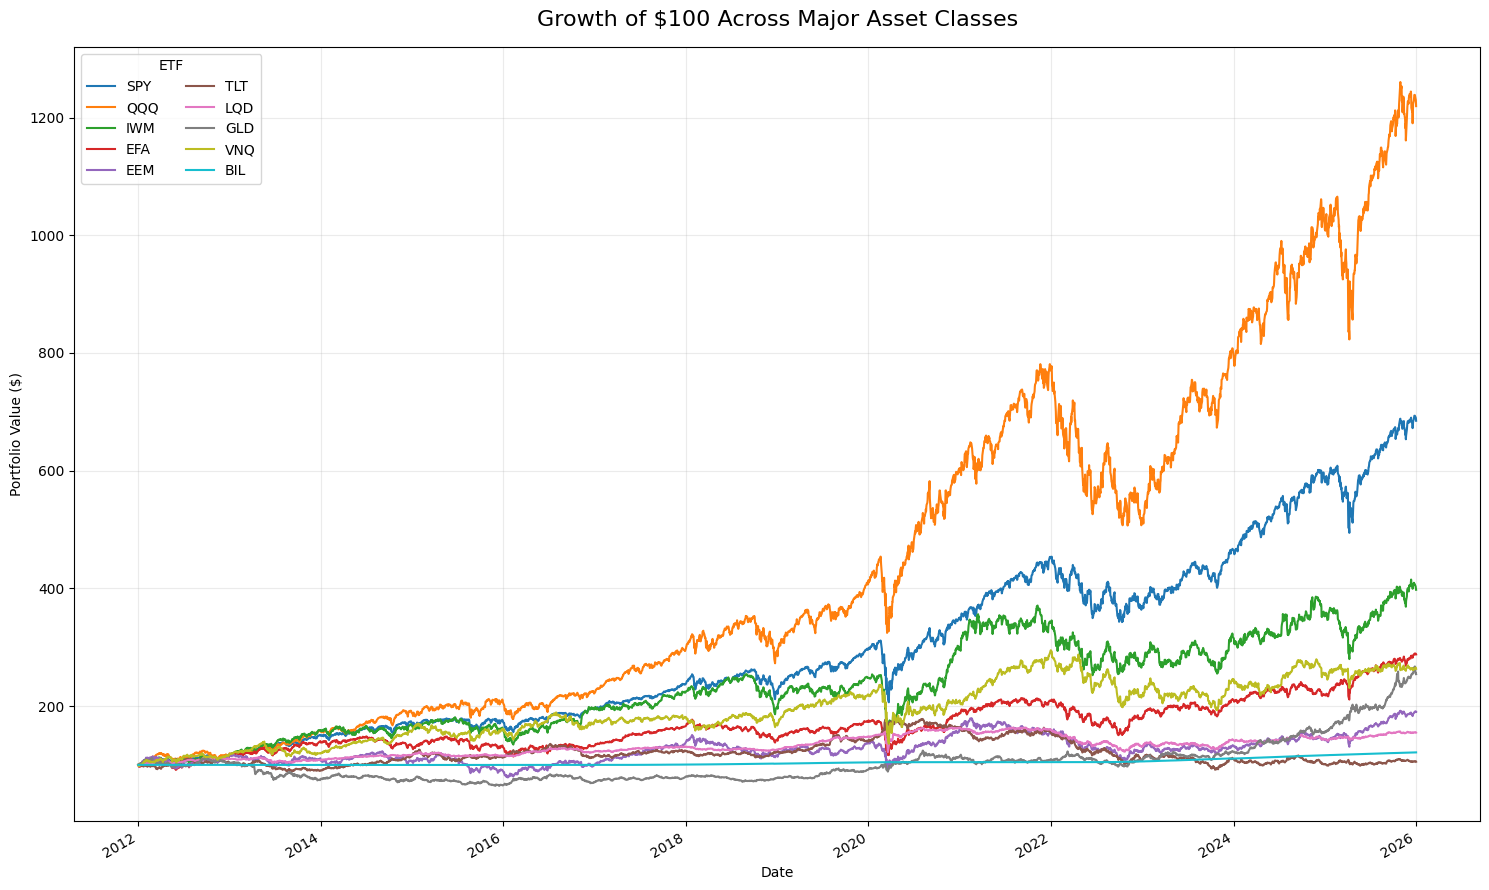

In [9]:
# ============================================================
# CELL 9: NORMALIZED ASSET GROWTH
# ============================================================

normalized_asset_growth = (
    analysis_prices
    / analysis_prices.iloc[0]
    * 100.0
)


ax = normalized_asset_growth.plot(
    figsize=(15, 9),
    linewidth=1.5,
)

ax.set_title(
    "Growth of $100 Across Major Asset Classes",
    fontsize=16,
    pad=15,
)

ax.set_xlabel("Date")
ax.set_ylabel("Portfolio Value ($)")
ax.grid(True, alpha=0.25)
ax.legend(
    title="ETF",
    ncol=2,
)

plt.tight_layout()
plt.show()

## 3. Cross-Asset Correlation Structure

Correlation measures how closely two assets tend to move together.

- A correlation near **+1** means the assets usually move in the same direction.
- A correlation near **0** means their movements have little linear
  relationship.
- A correlation near **−1** means they frequently move in opposite directions.

Diversification is most useful when a portfolio contains assets that are not
perfectly correlated.

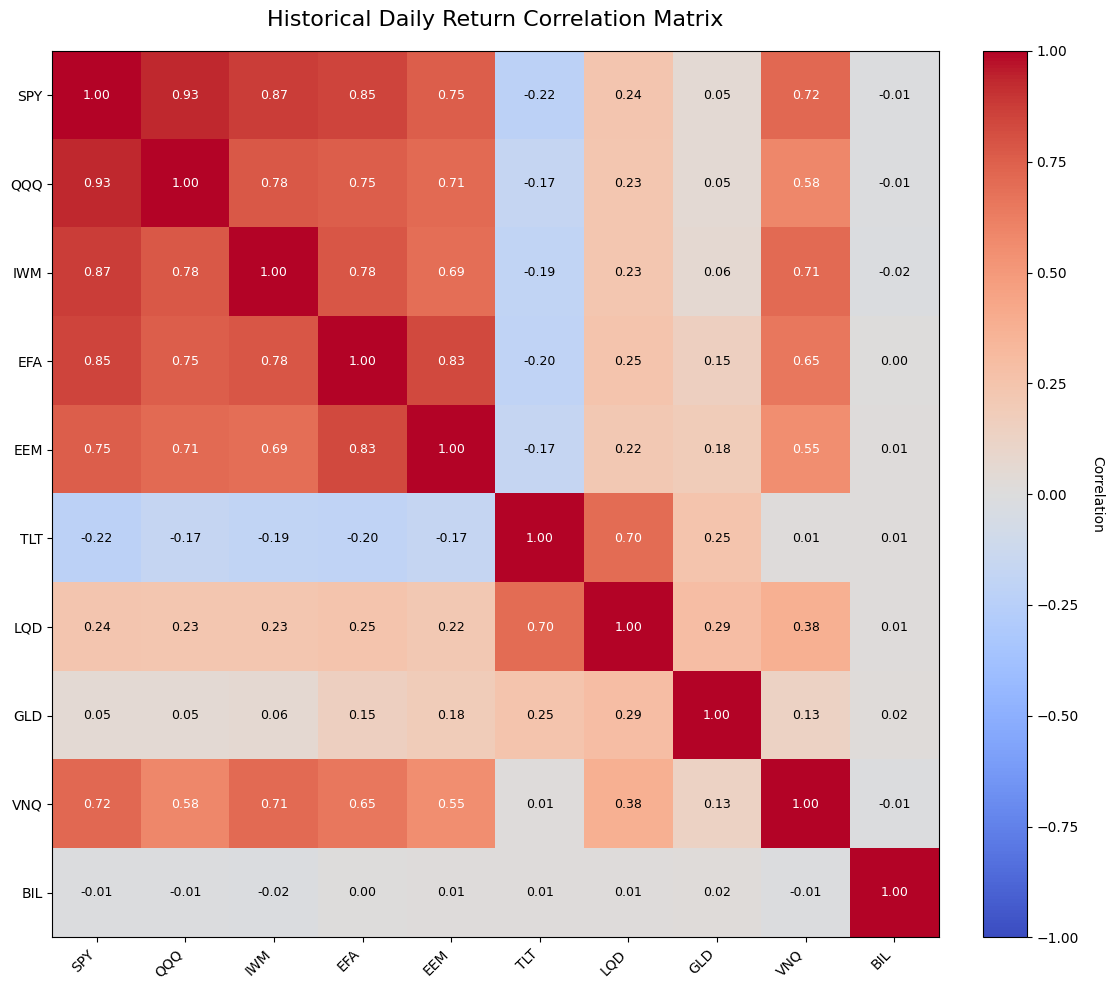

In [10]:
# ============================================================
# CELL 10: CROSS-ASSET CORRELATION HEATMAP
# ============================================================

fig, ax = plt.subplots(
    figsize=(12, 10)
)


heatmap = ax.imshow(
    correlation_matrix.to_numpy(),
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    aspect="equal",
)


ax.set_title(
    "Historical Daily Return Correlation Matrix",
    fontsize=16,
    pad=18,
)


ax.set_xticks(
    range(len(correlation_matrix.columns))
)

ax.set_xticklabels(
    correlation_matrix.columns,
    rotation=45,
    ha="right",
)


ax.set_yticks(
    range(len(correlation_matrix.index))
)

ax.set_yticklabels(
    correlation_matrix.index,
)


for row_position in range(
    correlation_matrix.shape[0]
):
    for column_position in range(
        correlation_matrix.shape[1]
    ):

        correlation_value = (
            correlation_matrix.iloc[
                row_position,
                column_position,
            ]
        )

        text_color = (
            "white"
            if abs(correlation_value) > 0.55
            else "black"
        )

        ax.text(
            column_position,
            row_position,
            f"{correlation_value:.2f}",
            ha="center",
            va="center",
            fontsize=9,
            color=text_color,
        )


colorbar = fig.colorbar(
    heatmap,
    ax=ax,
    fraction=0.046,
    pad=0.04,
)

colorbar.set_label(
    "Correlation",
    rotation=270,
    labelpad=18,
)


plt.tight_layout()
plt.show()

## 4. Portfolio Simulation and Mean-Variance Optimization

A portfolio's expected return is the weighted average of its assets' expected
returns.

Portfolio risk depends on both individual asset volatility and the correlations
between assets. Two risky assets can sometimes reduce total portfolio risk when
they do not move together perfectly.

This section:

- Generates 50,000 randomly weighted portfolios
- Applies a maximum 35% allocation limit to each ETF
- Calculates expected return, volatility, and Sharpe ratio
- Finds the maximum-Sharpe portfolio
- Finds the minimum-volatility portfolio
- Constructs the efficient frontier
- Produces two-dimensional and three-dimensional portfolio visualizations

In [11]:
# ============================================================
# CELL 11: PORTFOLIO MATHEMATICS
# ============================================================

NUMBER_OF_ASSETS = len(TICKERS)


def validate_portfolio_weights(
    weights: np.ndarray,
    tolerance: float = 1e-8,
) -> None:
    """Validate a portfolio-weight vector."""

    weights = np.asarray(
        weights,
        dtype=float,
    )

    if weights.ndim != 1:
        raise ValueError(
            "Portfolio weights must be one-dimensional."
        )

    if len(weights) != NUMBER_OF_ASSETS:
        raise ValueError(
            "The weight vector does not match the asset universe."
        )

    if not np.isfinite(weights).all():
        raise ValueError(
            "Portfolio weights contain invalid values."
        )

    if not np.isclose(
        weights.sum(),
        1.0,
        atol=tolerance,
    ):
        raise ValueError(
            "Portfolio weights must sum to 100%."
        )

    if (
        weights
        < CONFIG.minimum_asset_weight - tolerance
    ).any():
        raise ValueError(
            "A portfolio weight is below the allowed minimum."
        )

    if (
        weights
        > CONFIG.maximum_asset_weight + tolerance
    ).any():
        raise ValueError(
            "A portfolio weight exceeds the allowed maximum."
        )


def calculate_portfolio_return(
    weights: np.ndarray,
    expected_returns: pd.Series,
) -> float:
    """Calculate annualized expected portfolio return."""

    weights = np.asarray(
        weights,
        dtype=float,
    )

    return float(
        np.dot(
            weights,
            expected_returns.to_numpy(),
        )
    )


def calculate_portfolio_volatility(
    weights: np.ndarray,
    covariance_matrix: pd.DataFrame,
) -> float:
    """Calculate annualized portfolio volatility."""

    weights = np.asarray(
        weights,
        dtype=float,
    )

    variance = float(
        weights.T
        @ covariance_matrix.to_numpy()
        @ weights
    )

    variance = max(
        variance,
        0.0,
    )

    return float(
        np.sqrt(variance)
    )


def calculate_portfolio_sharpe(
    weights: np.ndarray,
    expected_returns: pd.Series,
    covariance_matrix: pd.DataFrame,
    risk_free_rate: float,
) -> float:
    """Calculate the annualized portfolio Sharpe ratio."""

    expected_return = calculate_portfolio_return(
        weights=weights,
        expected_returns=expected_returns,
    )

    volatility = calculate_portfolio_volatility(
        weights=weights,
        covariance_matrix=covariance_matrix,
    )

    if volatility <= 0:
        return np.nan

    return float(
        (
            expected_return
            - risk_free_rate
        )
        / volatility
    )


equal_weight_portfolio = np.repeat(
    1.0 / NUMBER_OF_ASSETS,
    NUMBER_OF_ASSETS,
)


validate_portfolio_weights(
    equal_weight_portfolio
)


equal_weight_return = calculate_portfolio_return(
    weights=equal_weight_portfolio,
    expected_returns=annualized_mean_returns,
)


equal_weight_volatility = calculate_portfolio_volatility(
    weights=equal_weight_portfolio,
    covariance_matrix=annualized_covariance_matrix,
)


equal_weight_sharpe = calculate_portfolio_sharpe(
    weights=equal_weight_portfolio,
    expected_returns=annualized_mean_returns,
    covariance_matrix=annualized_covariance_matrix,
    risk_free_rate=annualized_risk_free_rate,
)


print("Portfolio mathematics loaded successfully.")
print(
    f"Equal-weight expected return: "
    f"{equal_weight_return:.2%}"
)
print(
    f"Equal-weight volatility:      "
    f"{equal_weight_volatility:.2%}"
)
print(
    f"Equal-weight Sharpe ratio:    "
    f"{equal_weight_sharpe:.3f}"
)

Portfolio mathematics loaded successfully.
Equal-weight expected return: 8.58%
Equal-weight volatility:      10.66%
Equal-weight Sharpe ratio:    0.654


In [12]:
# ============================================================
# CELL 12: GENERATE RANDOM BOUNDED PORTFOLIOS
# ============================================================

def generate_bounded_random_weights(
    number_of_portfolios: int,
    number_of_assets: int,
    maximum_weight: float,
    random_seed: int,
) -> np.ndarray:
    """
    Generate long-only random portfolios whose weights sum to 100%.

    Dirichlet samples that violate the maximum allocation limit
    are rejected.
    """

    if number_of_portfolios <= 0:
        raise ValueError(
            "number_of_portfolios must be positive."
        )

    if maximum_weight < 1.0 / number_of_assets:
        raise ValueError(
            "The maximum weight is too small to form a valid portfolio."
        )

    random_generator = np.random.default_rng(
        random_seed
    )

    accepted_batches = []
    accepted_count = 0

    while accepted_count < number_of_portfolios:

        remaining = (
            number_of_portfolios
            - accepted_count
        )

        batch_size = max(
            remaining * 3,
            5_000,
        )

        candidate_weights = (
            random_generator.dirichlet(
                alpha=np.ones(number_of_assets),
                size=batch_size,
            )
        )

        valid_candidates = candidate_weights[
            candidate_weights.max(axis=1)
            <= maximum_weight
        ]

        if len(valid_candidates) == 0:
            continue

        accepted_batches.append(
            valid_candidates
        )

        accepted_count += len(
            valid_candidates
        )

    combined_weights = np.vstack(
        accepted_batches
    )

    return combined_weights[
        :number_of_portfolios
    ]


random_portfolio_weights = (
    generate_bounded_random_weights(
        number_of_portfolios=CONFIG.random_portfolios,
        number_of_assets=NUMBER_OF_ASSETS,
        maximum_weight=CONFIG.maximum_asset_weight,
        random_seed=RANDOM_SEED,
    )
)


expected_return_vector = (
    annualized_mean_returns
    .reindex(TICKERS)
    .to_numpy()
)


covariance_array = (
    annualized_covariance_matrix
    .reindex(
        index=TICKERS,
        columns=TICKERS,
    )
    .to_numpy()
)


random_portfolio_returns = (
    random_portfolio_weights
    @ expected_return_vector
)


random_portfolio_variances = np.einsum(
    "ij,jk,ik->i",
    random_portfolio_weights,
    covariance_array,
    random_portfolio_weights,
)


random_portfolio_volatility = np.sqrt(
    np.maximum(
        random_portfolio_variances,
        0.0,
    )
)


random_portfolio_sharpe = (
    random_portfolio_returns
    - annualized_risk_free_rate
) / random_portfolio_volatility


random_portfolio_results = pd.DataFrame(
    {
        "Expected Return":
            random_portfolio_returns,
        "Volatility":
            random_portfolio_volatility,
        "Sharpe Ratio":
            random_portfolio_sharpe,
    }
)


for asset_position, ticker in enumerate(TICKERS):
    random_portfolio_results[
        f"Weight {ticker}"
    ] = random_portfolio_weights[
        :,
        asset_position,
    ]


assert len(
    random_portfolio_results
) == CONFIG.random_portfolios

assert np.allclose(
    random_portfolio_weights.sum(axis=1),
    1.0,
)

assert (
    random_portfolio_weights.max(axis=1)
    <= CONFIG.maximum_asset_weight + 1e-10
).all()


print(
    f"{len(random_portfolio_results):,} "
    "valid random portfolios generated."
)

print(
    "Highest simulated Sharpe ratio: "
    f"{random_portfolio_results['Sharpe Ratio'].max():.3f}"
)

print(
    "Lowest simulated volatility: "
    f"{random_portfolio_results['Volatility'].min():.2%}"
)

display(
    random_portfolio_results[
        [
            "Expected Return",
            "Volatility",
            "Sharpe Ratio",
        ]
    ].describe()
)

50,000 valid random portfolios generated.
Highest simulated Sharpe ratio: 0.898
Lowest simulated volatility: 5.57%


,Expected Return,Volatility,Sharpe Ratio
count,"50,000.0000","50,000.0000","50,000.0000"
mean,0.0859,0.1104,0.6314
std,0.0153,0.0180,0.0869
min,0.0344,0.0557,0.2736
25%,0.0751,0.0975,0.5686
50%,0.0852,0.1099,0.6293
75%,0.0960,0.1229,0.6926
max,0.1470,0.1700,0.8982


In [13]:
# ============================================================
# CELL 13: OPTIMIZE MAXIMUM-SHARPE AND MINIMUM-VOLATILITY
# ============================================================

PORTFOLIO_BOUNDS = tuple(
    (
        CONFIG.minimum_asset_weight,
        CONFIG.maximum_asset_weight,
    )
    for _ in TICKERS
)


FULL_INVESTMENT_CONSTRAINT = {
    "type": "eq",
    "fun": lambda weights: (
        np.sum(weights)
        - 1.0
    ),
}


def negative_sharpe_objective(
    weights: np.ndarray,
) -> float:
    """Objective used to maximize the Sharpe ratio."""

    sharpe_ratio = calculate_portfolio_sharpe(
        weights=weights,
        expected_returns=annualized_mean_returns.reindex(
            TICKERS
        ),
        covariance_matrix=annualized_covariance_matrix.reindex(
            index=TICKERS,
            columns=TICKERS,
        ),
        risk_free_rate=annualized_risk_free_rate,
    )

    if not np.isfinite(sharpe_ratio):
        return 1e9

    return -sharpe_ratio


def volatility_objective(
    weights: np.ndarray,
) -> float:
    """Objective used to minimize portfolio volatility."""

    return calculate_portfolio_volatility(
        weights=weights,
        covariance_matrix=annualized_covariance_matrix.reindex(
            index=TICKERS,
            columns=TICKERS,
        ),
    )


maximum_sharpe_solution = minimize(
    fun=negative_sharpe_objective,
    x0=equal_weight_portfolio,
    method="SLSQP",
    bounds=PORTFOLIO_BOUNDS,
    constraints=[
        FULL_INVESTMENT_CONSTRAINT
    ],
    options={
        "maxiter": 2_000,
        "ftol": 1e-12,
        "disp": False,
    },
)


minimum_volatility_solution = minimize(
    fun=volatility_objective,
    x0=equal_weight_portfolio,
    method="SLSQP",
    bounds=PORTFOLIO_BOUNDS,
    constraints=[
        FULL_INVESTMENT_CONSTRAINT
    ],
    options={
        "maxiter": 2_000,
        "ftol": 1e-12,
        "disp": False,
    },
)


if not maximum_sharpe_solution.success:
    raise RuntimeError(
        "Maximum-Sharpe optimization failed: "
        + maximum_sharpe_solution.message
    )


if not minimum_volatility_solution.success:
    raise RuntimeError(
        "Minimum-volatility optimization failed: "
        + minimum_volatility_solution.message
    )


maximum_sharpe_weights = (
    maximum_sharpe_solution.x
)


minimum_volatility_weights = (
    minimum_volatility_solution.x
)


validate_portfolio_weights(
    maximum_sharpe_weights
)

validate_portfolio_weights(
    minimum_volatility_weights
)


def portfolio_summary(
    portfolio_name: str,
    weights: np.ndarray,
) -> pd.Series:
    """Create a summary of an optimized portfolio."""

    expected_return = calculate_portfolio_return(
        weights=weights,
        expected_returns=annualized_mean_returns.reindex(
            TICKERS
        ),
    )

    volatility = calculate_portfolio_volatility(
        weights=weights,
        covariance_matrix=annualized_covariance_matrix.reindex(
            index=TICKERS,
            columns=TICKERS,
        ),
    )

    sharpe_ratio = calculate_portfolio_sharpe(
        weights=weights,
        expected_returns=annualized_mean_returns.reindex(
            TICKERS
        ),
        covariance_matrix=annualized_covariance_matrix.reindex(
            index=TICKERS,
            columns=TICKERS,
        ),
        risk_free_rate=annualized_risk_free_rate,
    )

    return pd.Series(
        {
            "Expected Return": expected_return,
            "Volatility": volatility,
            "Sharpe Ratio": sharpe_ratio,
        },
        name=portfolio_name,
    )


optimized_portfolio_summary = pd.concat(
    [
        portfolio_summary(
            "Maximum-Sharpe",
            maximum_sharpe_weights,
        ),
        portfolio_summary(
            "Minimum-Volatility",
            minimum_volatility_weights,
        ),
        portfolio_summary(
            "Equal-Weight",
            equal_weight_portfolio,
        ),
    ],
    axis=1,
).T


optimized_weights_table = pd.DataFrame(
    {
        "Maximum-Sharpe":
            maximum_sharpe_weights,
        "Minimum-Volatility":
            minimum_volatility_weights,
        "Equal-Weight":
            equal_weight_portfolio,
    },
    index=TICKERS,
)


print("Portfolio optimization completed successfully.")

display(
    optimized_portfolio_summary.style.format(
        {
            "Expected Return": "{:.2%}",
            "Volatility": "{:.2%}",
            "Sharpe Ratio": "{:.3f}",
        }
    )
)

print()
print("Optimized portfolio weights:")

display(
    optimized_weights_table.style.format(
        "{:.2%}"
    )
)

Portfolio optimization completed successfully.


,Expected Return,Volatility,Sharpe Ratio
Maximum-Sharpe,10.20%,8.98%,0.957
Minimum-Volatility,4.36%,4.99%,0.551
Equal-Weight,8.58%,10.66%,0.654



Optimized portfolio weights:


,Maximum-Sharpe,Minimum-Volatility,Equal-Weight
SPY,6.30%,10.38%,10.00%
QQQ,35.00%,0.00%,10.00%
IWM,0.00%,0.00%,10.00%
EFA,0.00%,2.20%,10.00%
EEM,0.00%,0.00%,10.00%
TLT,4.24%,7.32%,10.00%
LQD,0.00%,35.00%,10.00%
GLD,21.90%,10.10%,10.00%
VNQ,0.00%,0.00%,10.00%
BIL,32.55%,35.00%,10.00%


In [14]:
# ============================================================
# CELL 14: CONSTRUCT THE EFFICIENT FRONTIER
# ============================================================

def negative_return_objective(
    weights: np.ndarray,
) -> float:
    """Objective used to locate the maximum-return feasible portfolio."""

    return -calculate_portfolio_return(
        weights=weights,
        expected_returns=annualized_mean_returns.reindex(
            TICKERS
        ),
    )


maximum_return_solution = minimize(
    fun=negative_return_objective,
    x0=equal_weight_portfolio,
    method="SLSQP",
    bounds=PORTFOLIO_BOUNDS,
    constraints=[
        FULL_INVESTMENT_CONSTRAINT
    ],
    options={
        "maxiter": 2_000,
        "ftol": 1e-12,
        "disp": False,
    },
)


if not maximum_return_solution.success:
    raise RuntimeError(
        "Maximum-return optimization failed: "
        + maximum_return_solution.message
    )


maximum_feasible_return = (
    calculate_portfolio_return(
        weights=maximum_return_solution.x,
        expected_returns=annualized_mean_returns.reindex(
            TICKERS
        ),
    )
)


minimum_volatility_return = (
    optimized_portfolio_summary.loc[
        "Minimum-Volatility",
        "Expected Return",
    ]
)


target_returns = np.linspace(
    minimum_volatility_return,
    maximum_feasible_return,
    70,
)


efficient_frontier_records = []


for target_return in target_returns:

    target_return_constraint = {
        "type": "eq",
        "fun": (
            lambda weights,
            target=target_return:
            calculate_portfolio_return(
                weights=weights,
                expected_returns=annualized_mean_returns.reindex(
                    TICKERS
                ),
            )
            - target
        ),
    }

    frontier_solution = minimize(
        fun=volatility_objective,
        x0=equal_weight_portfolio,
        method="SLSQP",
        bounds=PORTFOLIO_BOUNDS,
        constraints=[
            FULL_INVESTMENT_CONSTRAINT,
            target_return_constraint,
        ],
        options={
            "maxiter": 2_000,
            "ftol": 1e-11,
            "disp": False,
        },
    )

    if not frontier_solution.success:
        continue

    frontier_weights = (
        frontier_solution.x
    )

    frontier_volatility = (
        calculate_portfolio_volatility(
            weights=frontier_weights,
            covariance_matrix=
                annualized_covariance_matrix.reindex(
                    index=TICKERS,
                    columns=TICKERS,
                ),
        )
    )

    frontier_sharpe = (
        target_return
        - annualized_risk_free_rate
    ) / frontier_volatility

    frontier_record = {
        "Expected Return": target_return,
        "Volatility": frontier_volatility,
        "Sharpe Ratio": frontier_sharpe,
    }

    for asset_position, ticker in enumerate(
        TICKERS
    ):
        frontier_record[
            f"Weight {ticker}"
        ] = frontier_weights[
            asset_position
        ]

    efficient_frontier_records.append(
        frontier_record
    )


efficient_frontier = (
    pd.DataFrame(
        efficient_frontier_records
    )
    .sort_values("Volatility")
    .drop_duplicates(
        subset=[
            "Expected Return",
            "Volatility",
        ]
    )
    .reset_index(drop=True)
)


if efficient_frontier.empty:
    raise RuntimeError(
        "The efficient frontier could not be constructed."
    )


print("Efficient frontier constructed successfully.")
print(
    f"Successful frontier portfolios: "
    f"{len(efficient_frontier)}"
)
print(
    f"Frontier return range: "
    f"{efficient_frontier['Expected Return'].min():.2%} "
    f"to "
    f"{efficient_frontier['Expected Return'].max():.2%}"
)

display(
    efficient_frontier[
        [
            "Expected Return",
            "Volatility",
            "Sharpe Ratio",
        ]
    ].head()
)

Efficient frontier constructed successfully.
Successful frontier portfolios: 70
Frontier return range: 4.36% to 15.96%


,Expected Return,Volatility,Sharpe Ratio
0,0.0436,0.0499,0.5514
1,0.0452,0.0499,0.5847
2,0.0469,0.0501,0.6166
3,0.0486,0.0504,0.6461
4,0.0503,0.0509,0.6730


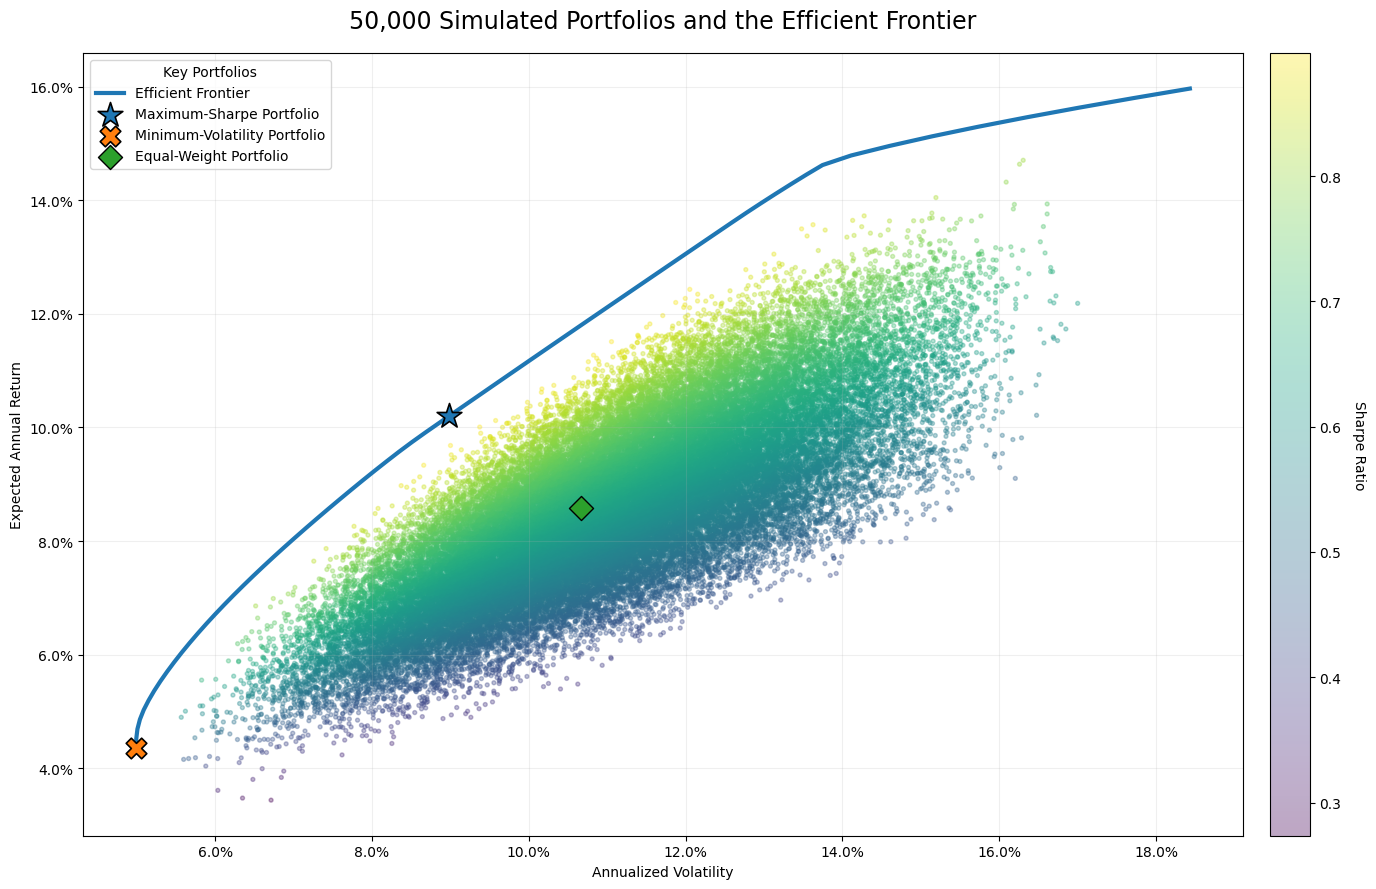

In [15]:
# ============================================================
# CELL 15: EFFICIENT FRONTIER VISUALIZATION
# ============================================================

maximum_sharpe_return = (
    optimized_portfolio_summary.loc[
        "Maximum-Sharpe",
        "Expected Return",
    ]
)

maximum_sharpe_volatility = (
    optimized_portfolio_summary.loc[
        "Maximum-Sharpe",
        "Volatility",
    ]
)

minimum_volatility_expected_return = (
    optimized_portfolio_summary.loc[
        "Minimum-Volatility",
        "Expected Return",
    ]
)

minimum_volatility_risk = (
    optimized_portfolio_summary.loc[
        "Minimum-Volatility",
        "Volatility",
    ]
)


fig, ax = plt.subplots(
    figsize=(15, 9)
)


portfolio_cloud = ax.scatter(
    random_portfolio_results[
        "Volatility"
    ],
    random_portfolio_results[
        "Expected Return"
    ],
    c=random_portfolio_results[
        "Sharpe Ratio"
    ],
    cmap="viridis",
    s=8,
    alpha=0.35,
)


ax.plot(
    efficient_frontier[
        "Volatility"
    ],
    efficient_frontier[
        "Expected Return"
    ],
    linewidth=3,
    label="Efficient Frontier",
)


ax.scatter(
    maximum_sharpe_volatility,
    maximum_sharpe_return,
    marker="*",
    s=350,
    edgecolor="black",
    linewidth=1.2,
    label="Maximum-Sharpe Portfolio",
    zorder=5,
)


ax.scatter(
    minimum_volatility_risk,
    minimum_volatility_expected_return,
    marker="X",
    s=220,
    edgecolor="black",
    linewidth=1.2,
    label="Minimum-Volatility Portfolio",
    zorder=5,
)


ax.scatter(
    equal_weight_volatility,
    equal_weight_return,
    marker="D",
    s=150,
    edgecolor="black",
    linewidth=1.0,
    label="Equal-Weight Portfolio",
    zorder=5,
)


ax.set_title(
    "50,000 Simulated Portfolios and the Efficient Frontier",
    fontsize=17,
    pad=18,
)

ax.set_xlabel(
    "Annualized Volatility"
)

ax.set_ylabel(
    "Expected Annual Return"
)


ax.xaxis.set_major_formatter(
    PercentFormatter(1.0)
)

ax.yaxis.set_major_formatter(
    PercentFormatter(1.0)
)


ax.grid(
    True,
    alpha=0.20,
)

ax.legend(
    title="Key Portfolios",
    loc="best",
)


colorbar = fig.colorbar(
    portfolio_cloud,
    ax=ax,
    pad=0.02,
)

colorbar.set_label(
    "Sharpe Ratio",
    rotation=270,
    labelpad=18,
)


plt.tight_layout()
plt.show()

### Three-Dimensional Portfolio Opportunity Set

The three-dimensional graph displays:

- **X-axis:** annualized portfolio volatility
- **Y-axis:** expected annual return
- **Z-axis:** Sharpe ratio

Each point represents a different simulated ETF allocation. The surface-like
shape illustrates how return and risk interact across thousands of possible
portfolios.

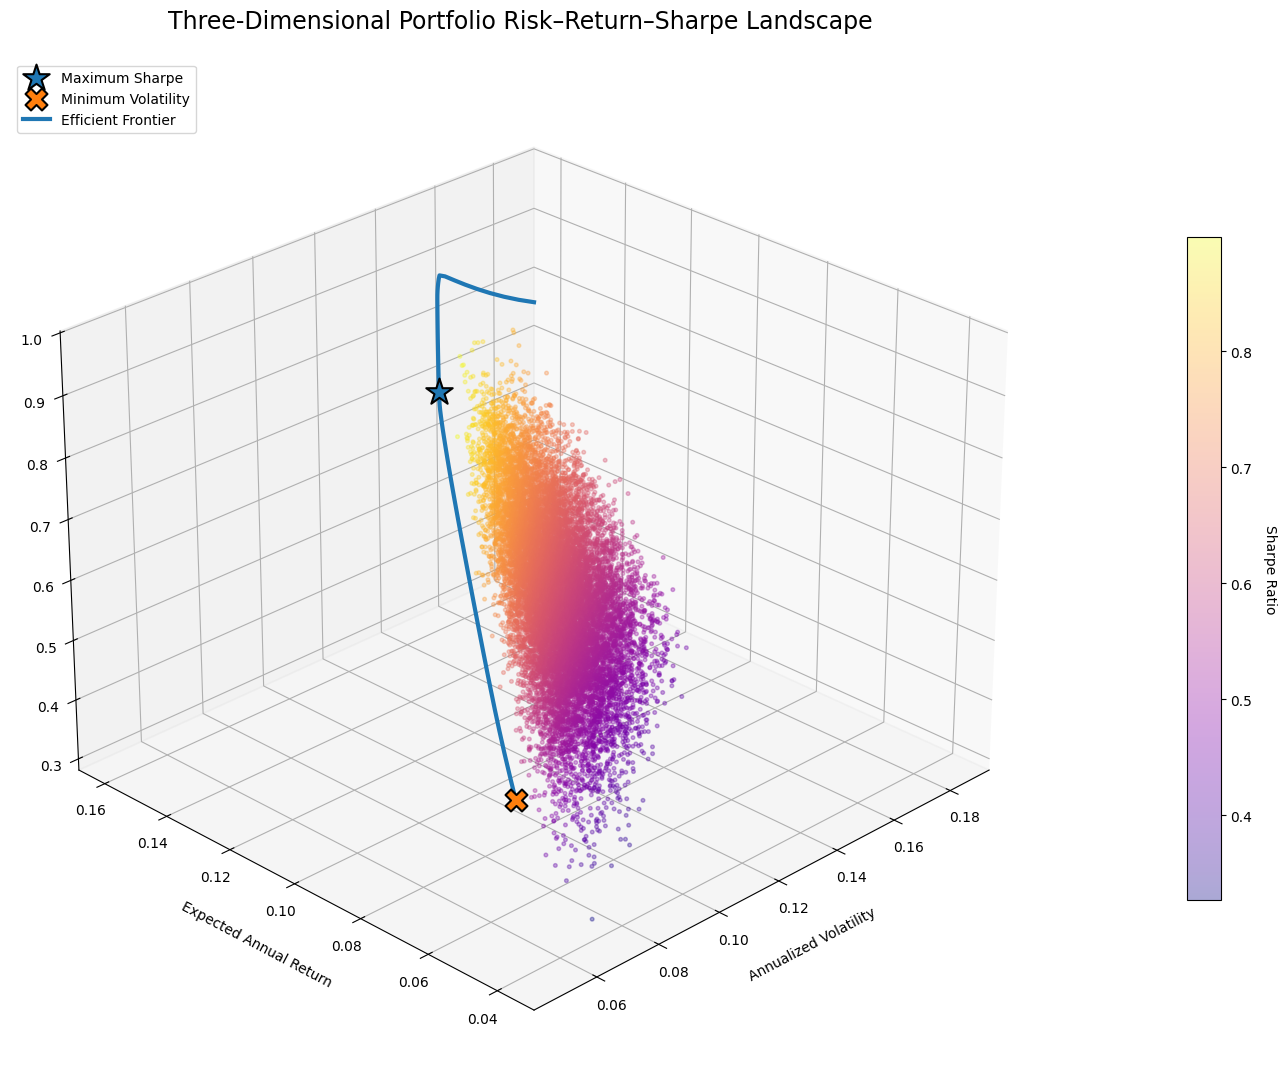

In [16]:
# ============================================================
# CELL 16: THREE-DIMENSIONAL PORTFOLIO CLOUD
# ============================================================

from mpl_toolkits.mplot3d import Axes3D


# Plot a representative sample so the 3D chart remains responsive.
THREE_DIMENSIONAL_SAMPLE_SIZE = min(
    15_000,
    len(random_portfolio_results),
)


three_dimensional_sample = (
    random_portfolio_results.sample(
        n=THREE_DIMENSIONAL_SAMPLE_SIZE,
        random_state=RANDOM_SEED,
    )
)


fig = plt.figure(
    figsize=(16, 11)
)


ax = fig.add_subplot(
    111,
    projection="3d",
)


three_dimensional_cloud = ax.scatter(
    three_dimensional_sample[
        "Volatility"
    ],
    three_dimensional_sample[
        "Expected Return"
    ],
    three_dimensional_sample[
        "Sharpe Ratio"
    ],
    c=three_dimensional_sample[
        "Sharpe Ratio"
    ],
    cmap="plasma",
    s=7,
    alpha=0.35,
)


ax.scatter(
    maximum_sharpe_volatility,
    maximum_sharpe_return,
    optimized_portfolio_summary.loc[
        "Maximum-Sharpe",
        "Sharpe Ratio",
    ],
    marker="*",
    s=400,
    edgecolor="black",
    linewidth=1.5,
    label="Maximum Sharpe",
)


ax.scatter(
    minimum_volatility_risk,
    minimum_volatility_expected_return,
    optimized_portfolio_summary.loc[
        "Minimum-Volatility",
        "Sharpe Ratio",
    ],
    marker="X",
    s=250,
    edgecolor="black",
    linewidth=1.5,
    label="Minimum Volatility",
)


ax.plot(
    efficient_frontier[
        "Volatility"
    ],
    efficient_frontier[
        "Expected Return"
    ],
    efficient_frontier[
        "Sharpe Ratio"
    ],
    linewidth=3,
    label="Efficient Frontier",
)


ax.set_title(
    "Three-Dimensional Portfolio Risk–Return–Sharpe Landscape",
    fontsize=17,
    pad=22,
)


ax.set_xlabel(
    "Annualized Volatility",
    labelpad=12,
)

ax.set_ylabel(
    "Expected Annual Return",
    labelpad=12,
)

ax.set_zlabel(
    "Sharpe Ratio",
    labelpad=12,
)


ax.view_init(
    elev=27,
    azim=225,
)


ax.legend(
    loc="upper left"
)


colorbar = fig.colorbar(
    three_dimensional_cloud,
    ax=ax,
    shrink=0.65,
    pad=0.10,
)

colorbar.set_label(
    "Sharpe Ratio",
    rotation=270,
    labelpad=18,
)


plt.tight_layout()
plt.show()

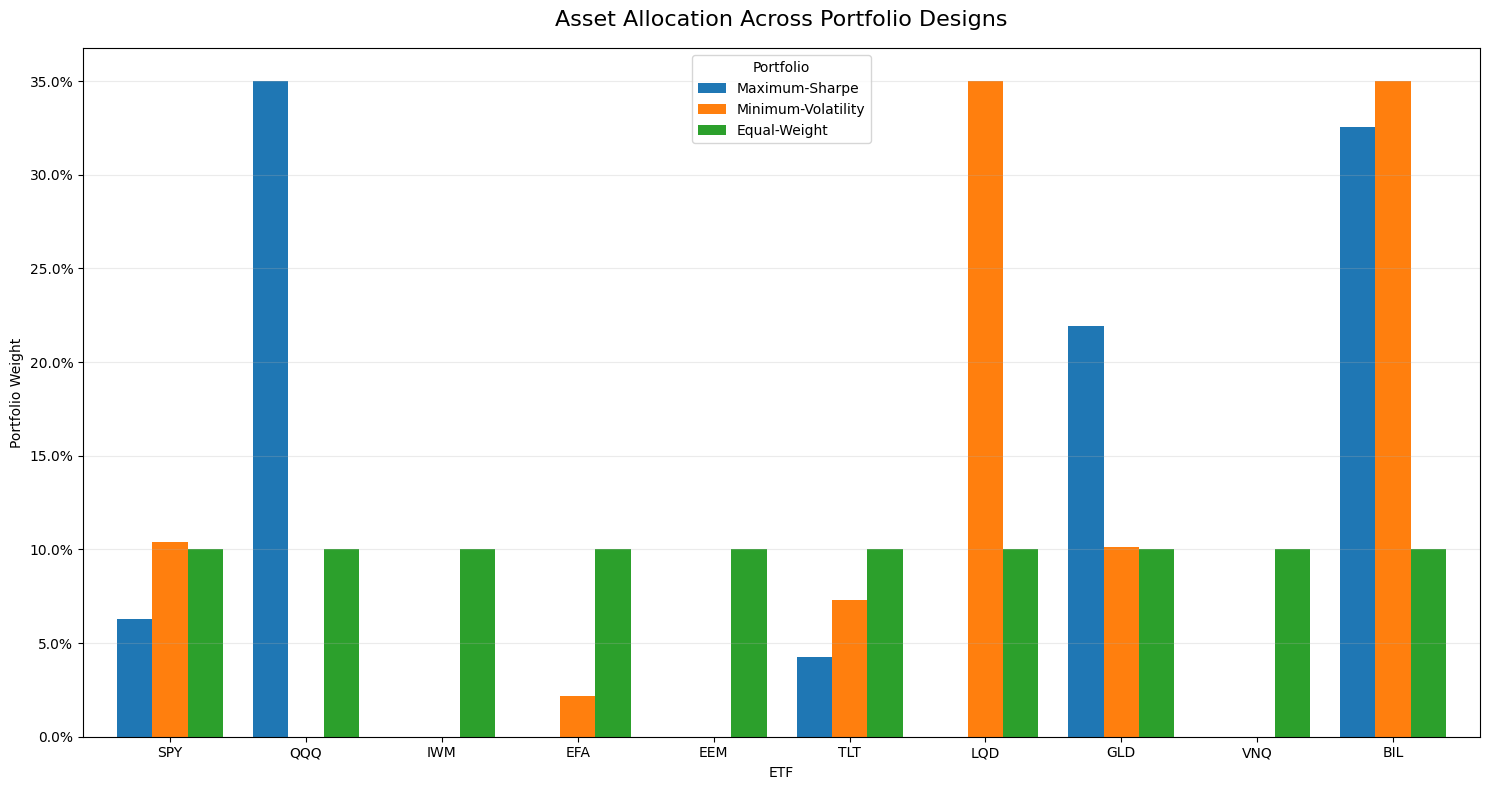

Maximum-Sharpe allocation:


,Maximum-Sharpe
QQQ,35.00%
BIL,32.55%
GLD,21.90%
SPY,6.30%
TLT,4.24%
EFA,0.00%
LQD,0.00%
EEM,0.00%
IWM,0.00%
VNQ,0.00%


In [17]:
# ============================================================
# CELL 17: OPTIMIZED ALLOCATION COMPARISON
# ============================================================

allocation_comparison = (
    optimized_weights_table
    .copy()
)


ax = allocation_comparison.plot(
    kind="bar",
    figsize=(15, 8),
    width=0.78,
)


ax.set_title(
    "Asset Allocation Across Portfolio Designs",
    fontsize=16,
    pad=16,
)

ax.set_xlabel(
    "ETF"
)

ax.set_ylabel(
    "Portfolio Weight"
)


ax.yaxis.set_major_formatter(
    PercentFormatter(1.0)
)


ax.grid(
    True,
    axis="y",
    alpha=0.25,
)

ax.legend(
    title="Portfolio"
)


plt.xticks(
    rotation=0
)

plt.tight_layout()
plt.show()


print("Maximum-Sharpe allocation:")

display(
    optimized_weights_table[
        ["Maximum-Sharpe"]
    ]
    .sort_values(
        "Maximum-Sharpe",
        ascending=False,
    )
    .style.format(
        "{:.2%}"
    )
)

## 5. Correlated Monte Carlo Portfolio Simulation

Monte Carlo simulation generates many possible future market paths rather than
producing a single forecast.

The model estimates monthly return and correlation relationships from historical
ETF data, then generates correlated random returns for all assets.

The maximum-Sharpe portfolio is rebalanced monthly. Portfolio weights drift as
assets move during each month, and transaction costs are deducted when the
portfolio is restored to its target allocation.

The simulation is not a prediction. Its results depend on the historical data
and statistical assumptions used by the model.

In [18]:
# ============================================================
# CELL 18: PREPARE MONTHLY MONTE CARLO MODEL
# ============================================================

monthly_prices = (
    analysis_prices
    .resample("ME")
    .last()
)


monthly_simple_returns = (
    monthly_prices
    .pct_change(fill_method=None)
    .dropna(how="any")
    .reindex(columns=TICKERS)
)


# Log returns are convenient for simulation because converting
# them back with exp(return) - 1 guarantees returns above -100%.
monthly_log_returns = np.log1p(
    monthly_simple_returns
)


monthly_log_mean = (
    monthly_log_returns
    .mean()
    .reindex(TICKERS)
)


monthly_log_covariance = (
    monthly_log_returns
    .cov()
    .reindex(
        index=TICKERS,
        columns=TICKERS,
    )
)


assert monthly_log_returns.notna().all().all()
assert np.isfinite(monthly_log_returns).all().all()
assert np.isfinite(monthly_log_mean).all()
assert np.isfinite(monthly_log_covariance).all().all()


SIMULATION_MONTHS = (
    CONFIG.simulation_years
    * CONFIG.months_per_year
)


MONTE_CARLO_TARGET_WEIGHTS = (
    maximum_sharpe_weights.copy()
)


validate_portfolio_weights(
    MONTE_CARLO_TARGET_WEIGHTS
)


monthly_model_summary = pd.DataFrame(
    {
        "Monthly Log-Return Mean":
            monthly_log_mean,
        "Monthly Volatility":
            np.sqrt(
                np.diag(
                    monthly_log_covariance
                )
            ),
        "Annualized Approximate Volatility":
            np.sqrt(
                np.diag(
                    monthly_log_covariance
                )
                * CONFIG.months_per_year
            ),
    },
    index=TICKERS,
)


print("Monthly Monte Carlo model prepared.")
print(
    f"Historical monthly observations: "
    f"{len(monthly_log_returns):,}"
)
print(
    f"Simulation months per path: "
    f"{SIMULATION_MONTHS}"
)
print(
    f"Monte Carlo paths: "
    f"{CONFIG.monte_carlo_paths:,}"
)

display(
    monthly_model_summary.style.format(
        {
            "Monthly Log-Return Mean": "{:.3%}",
            "Monthly Volatility": "{:.3%}",
            "Annualized Approximate Volatility": "{:.2%}",
        }
    )
)

Monthly Monte Carlo model prepared.
Historical monthly observations: 167
Simulation months per path: 120
Monte Carlo paths: 10,000


,Monthly Log-Return Mean,Monthly Volatility,Annualized Approximate Volatility
SPY,1.134%,4.017%,13.92%
QQQ,1.461%,4.883%,16.91%
IWM,0.795%,5.497%,19.04%
EFA,0.618%,4.176%,14.47%
EEM,0.341%,4.708%,16.31%
TLT,0.024%,3.804%,13.18%
LQD,0.248%,2.172%,7.53%
GLD,0.509%,4.240%,14.69%
VNQ,0.547%,4.855%,16.82%
BIL,0.115%,0.159%,0.55%


In [19]:
# ============================================================
# CELL 19: CORRELATED MONTE CARLO SIMULATION ENGINE
# ============================================================

def make_positive_semidefinite(
    covariance_matrix: np.ndarray,
    minimum_eigenvalue: float = 1e-10,
) -> np.ndarray:
    """
    Repair tiny numerical problems in a covariance matrix.

    Negative eigenvalues can appear because of floating-point
    rounding even when the original covariance estimate is valid.
    """

    symmetric_matrix = (
        covariance_matrix
        + covariance_matrix.T
    ) / 2.0

    eigenvalues, eigenvectors = np.linalg.eigh(
        symmetric_matrix
    )

    repaired_eigenvalues = np.maximum(
        eigenvalues,
        minimum_eigenvalue,
    )

    repaired_matrix = (
        eigenvectors
        @ np.diag(repaired_eigenvalues)
        @ eigenvectors.T
    )

    return (
        repaired_matrix
        + repaired_matrix.T
    ) / 2.0


def simulate_monthly_rebalanced_portfolio(
    target_weights: np.ndarray,
    monthly_log_return_mean: pd.Series,
    monthly_log_return_covariance: pd.DataFrame,
    initial_capital: float,
    number_of_paths: int,
    number_of_months: int,
    transaction_cost_bps: float,
    random_seed: int,
) -> dict[str, np.ndarray]:
    """
    Simulate correlated monthly asset returns and a portfolio that
    is rebalanced to fixed target weights at each month-end.

    Transaction costs are charged on gross traded notional.
    """

    target_weights = np.asarray(
        target_weights,
        dtype=float,
    )

    number_of_assets = len(
        target_weights
    )

    if number_of_paths <= 0:
        raise ValueError(
            "number_of_paths must be positive."
        )

    if number_of_months <= 0:
        raise ValueError(
            "number_of_months must be positive."
        )

    if initial_capital <= 0:
        raise ValueError(
            "initial_capital must be positive."
        )

    if not np.isclose(
        target_weights.sum(),
        1.0,
    ):
        raise ValueError(
            "Target weights must sum to 100%."
        )

    mean_vector = (
        monthly_log_return_mean
        .to_numpy(dtype=float)
    )

    covariance_array = (
        monthly_log_return_covariance
        .to_numpy(dtype=float)
    )

    repaired_covariance = (
        make_positive_semidefinite(
            covariance_array
        )
    )

    cholesky_factor = np.linalg.cholesky(
        repaired_covariance
    )

    random_generator = np.random.default_rng(
        random_seed
    )

    wealth_paths = np.empty(
        (
            number_of_paths,
            number_of_months + 1,
        ),
        dtype=float,
    )

    one_way_turnover = np.zeros(
        (
            number_of_paths,
            number_of_months,
        ),
        dtype=float,
    )

    transaction_costs = np.zeros(
        (
            number_of_paths,
            number_of_months,
        ),
        dtype=float,
    )

    wealth_paths[:, 0] = initial_capital

    transaction_cost_rate = (
        transaction_cost_bps
        / 10_000.0
    )

    for month_position in range(
        number_of_months
    ):

        independent_shocks = (
            random_generator.standard_normal(
                size=(
                    number_of_paths,
                    number_of_assets,
                )
            )
        )

        correlated_log_returns = (
            mean_vector
            + independent_shocks
            @ cholesky_factor.T
        )

        simulated_asset_returns = np.expm1(
            correlated_log_returns
        )

        beginning_wealth = wealth_paths[
            :,
            month_position,
        ]

        ending_asset_values = (
            beginning_wealth[:, None]
            * target_weights[None, :]
            * (
                1.0
                + simulated_asset_returns
            )
        )

        pre_rebalance_wealth = (
            ending_asset_values.sum(
                axis=1
            )
        )

        if (
            pre_rebalance_wealth <= 0
        ).any():
            raise RuntimeError(
                "A simulated portfolio reached a nonpositive value."
            )

        drifted_weights = (
            ending_asset_values
            / pre_rebalance_wealth[:, None]
        )

        gross_turnover = np.abs(
            target_weights[None, :]
            - drifted_weights
        ).sum(axis=1)

        one_way_turnover[
            :,
            month_position,
        ] = (
            gross_turnover / 2.0
        )

        # No final rebalance is required at the end of the horizon.
        if month_position < number_of_months - 1:

            monthly_cost = (
                pre_rebalance_wealth
                * gross_turnover
                * transaction_cost_rate
            )

        else:
            monthly_cost = np.zeros(
                number_of_paths
            )

        transaction_costs[
            :,
            month_position,
        ] = monthly_cost

        wealth_paths[
            :,
            month_position + 1,
        ] = (
            pre_rebalance_wealth
            - monthly_cost
        )

    return {
        "wealth_paths": wealth_paths,
        "one_way_turnover": one_way_turnover,
        "transaction_costs": transaction_costs,
        "repaired_covariance": repaired_covariance,
    }


MONTE_CARLO_OUTPUT = (
    simulate_monthly_rebalanced_portfolio(
        target_weights=
            MONTE_CARLO_TARGET_WEIGHTS,
        monthly_log_return_mean=
            monthly_log_mean,
        monthly_log_return_covariance=
            monthly_log_covariance,
        initial_capital=
            CONFIG.initial_capital,
        number_of_paths=
            CONFIG.monte_carlo_paths,
        number_of_months=
            SIMULATION_MONTHS,
        transaction_cost_bps=
            CONFIG.transaction_cost_bps,
        random_seed=
            RANDOM_SEED,
    )
)


monte_carlo_wealth_paths = (
    MONTE_CARLO_OUTPUT[
        "wealth_paths"
    ]
)


monte_carlo_turnover = (
    MONTE_CARLO_OUTPUT[
        "one_way_turnover"
    ]
)


monte_carlo_transaction_costs = (
    MONTE_CARLO_OUTPUT[
        "transaction_costs"
    ]
)


assert monte_carlo_wealth_paths.shape == (
    CONFIG.monte_carlo_paths,
    SIMULATION_MONTHS + 1,
)

assert np.isfinite(
    monte_carlo_wealth_paths
).all()

assert (
    monte_carlo_wealth_paths > 0
).all()


print("Monte Carlo simulation completed successfully.")
print(
    f"Paths simulated: "
    f"{monte_carlo_wealth_paths.shape[0]:,}"
)
print(
    f"Months per path: "
    f"{monte_carlo_wealth_paths.shape[1] - 1}"
)
print(
    "Average simulated monthly one-way turnover: "
    f"{monte_carlo_turnover.mean():.2%}"
)
print(
    "Average total simulated transaction cost: "
    f"${monte_carlo_transaction_costs.sum(axis=1).mean():,.2f}"
)

Monte Carlo simulation completed successfully.
Paths simulated: 10,000
Months per path: 120
Average simulated monthly one-way turnover: 1.19%
Average total simulated transaction cost: $237.82


### Monte Carlo Fan Chart

The fan chart shows the range of simulated portfolio values over time.

The central line represents the median outcome. The surrounding bands show
increasingly wider ranges of possible outcomes.

A wider fan means that uncertainty grows as the investment horizon increases.

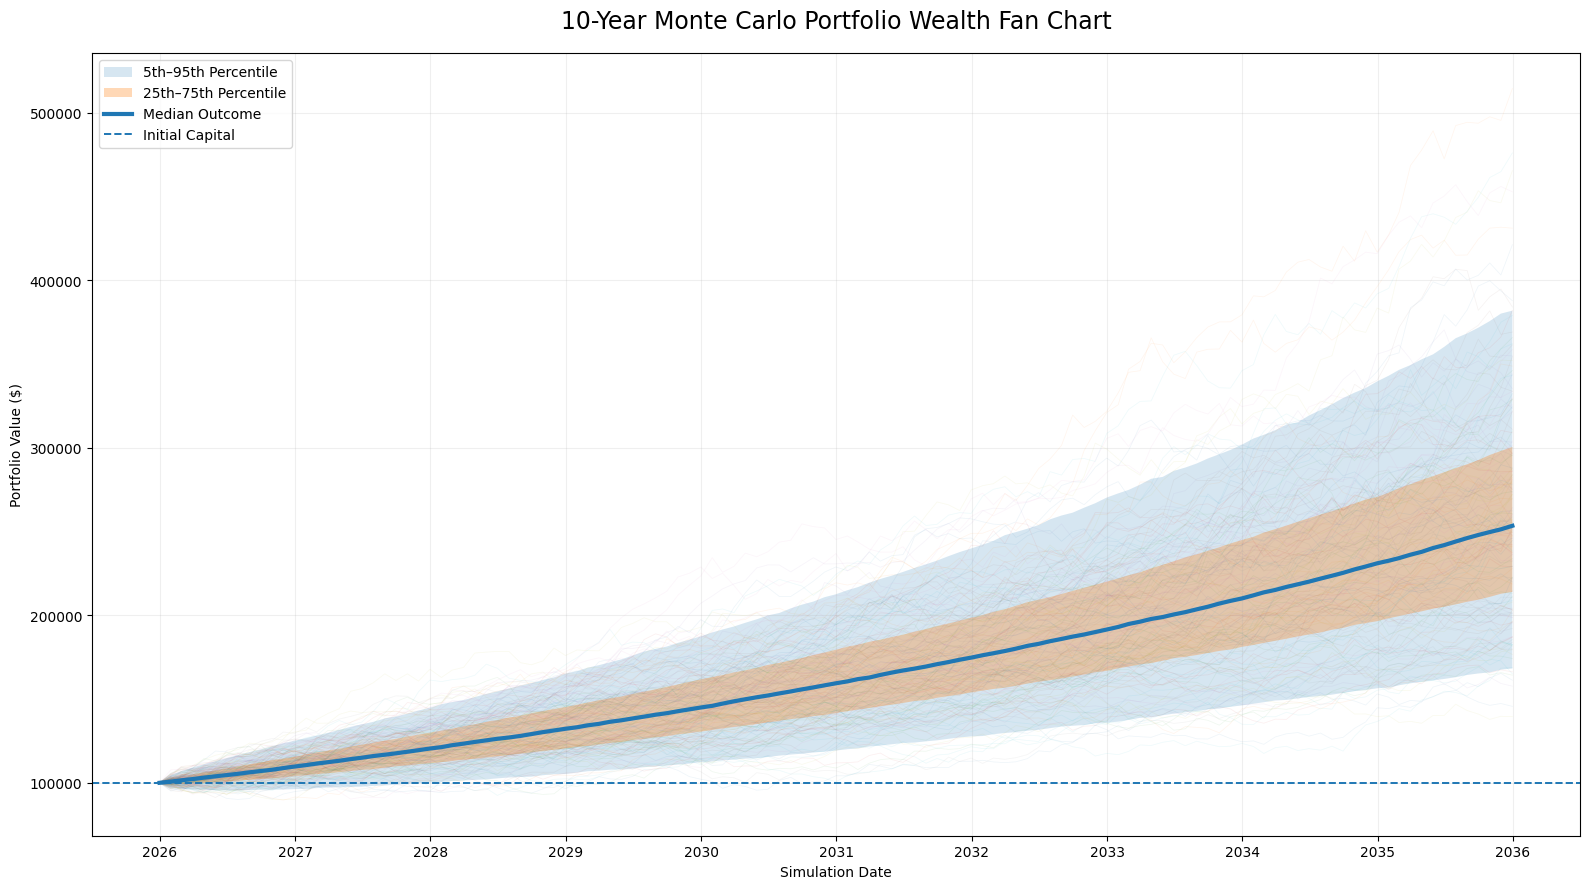

In [20]:
# ============================================================
# CELL 20: MONTE CARLO FAN CHART
# ============================================================

simulation_dates = pd.date_range(
    start=pd.Timestamp(
        CONFIG.analysis_end
    ),
    periods=SIMULATION_MONTHS + 1,
    freq="ME",
)


wealth_percentiles = np.percentile(
    monte_carlo_wealth_paths,
    [
        5,
        25,
        50,
        75,
        95,
    ],
    axis=0,
)


percentile_5 = wealth_percentiles[0]
percentile_25 = wealth_percentiles[1]
percentile_50 = wealth_percentiles[2]
percentile_75 = wealth_percentiles[3]
percentile_95 = wealth_percentiles[4]


random_generator = np.random.default_rng(
    RANDOM_SEED
)


sample_path_indices = (
    random_generator.choice(
        monte_carlo_wealth_paths.shape[0],
        size=min(
            150,
            monte_carlo_wealth_paths.shape[0],
        ),
        replace=False,
    )
)


fig, ax = plt.subplots(
    figsize=(16, 9)
)


for path_index in sample_path_indices:

    ax.plot(
        simulation_dates,
        monte_carlo_wealth_paths[
            path_index
        ],
        linewidth=0.55,
        alpha=0.07,
    )


ax.fill_between(
    simulation_dates,
    percentile_5,
    percentile_95,
    alpha=0.18,
    label="5th–95th Percentile",
)


ax.fill_between(
    simulation_dates,
    percentile_25,
    percentile_75,
    alpha=0.30,
    label="25th–75th Percentile",
)


ax.plot(
    simulation_dates,
    percentile_50,
    linewidth=3,
    label="Median Outcome",
)


ax.axhline(
    CONFIG.initial_capital,
    linestyle="--",
    linewidth=1.4,
    label="Initial Capital",
)


ax.set_title(
    "10-Year Monte Carlo Portfolio Wealth Fan Chart",
    fontsize=17,
    pad=18,
)

ax.set_xlabel(
    "Simulation Date"
)

ax.set_ylabel(
    "Portfolio Value ($)"
)

ax.grid(
    True,
    alpha=0.20,
)

ax.legend(
    loc="upper left"
)


plt.tight_layout()
plt.show()

Ten-year terminal-wealth summary:


,Monte Carlo Result
Initial Capital,"100,000.0000"
Mean Terminal Wealth,"261,676.0547"
Median Terminal Wealth,"253,414.9954"
5th Percentile Wealth,"168,225.9940"
25th Percentile Wealth,"213,970.5667"
75th Percentile Wealth,"300,465.6329"
95th Percentile Wealth,"381,819.1743"
Expected Shortfall Wealth,"152,527.1993"
Median Simulated CAGR,0.0974
Probability of Loss,0.0000


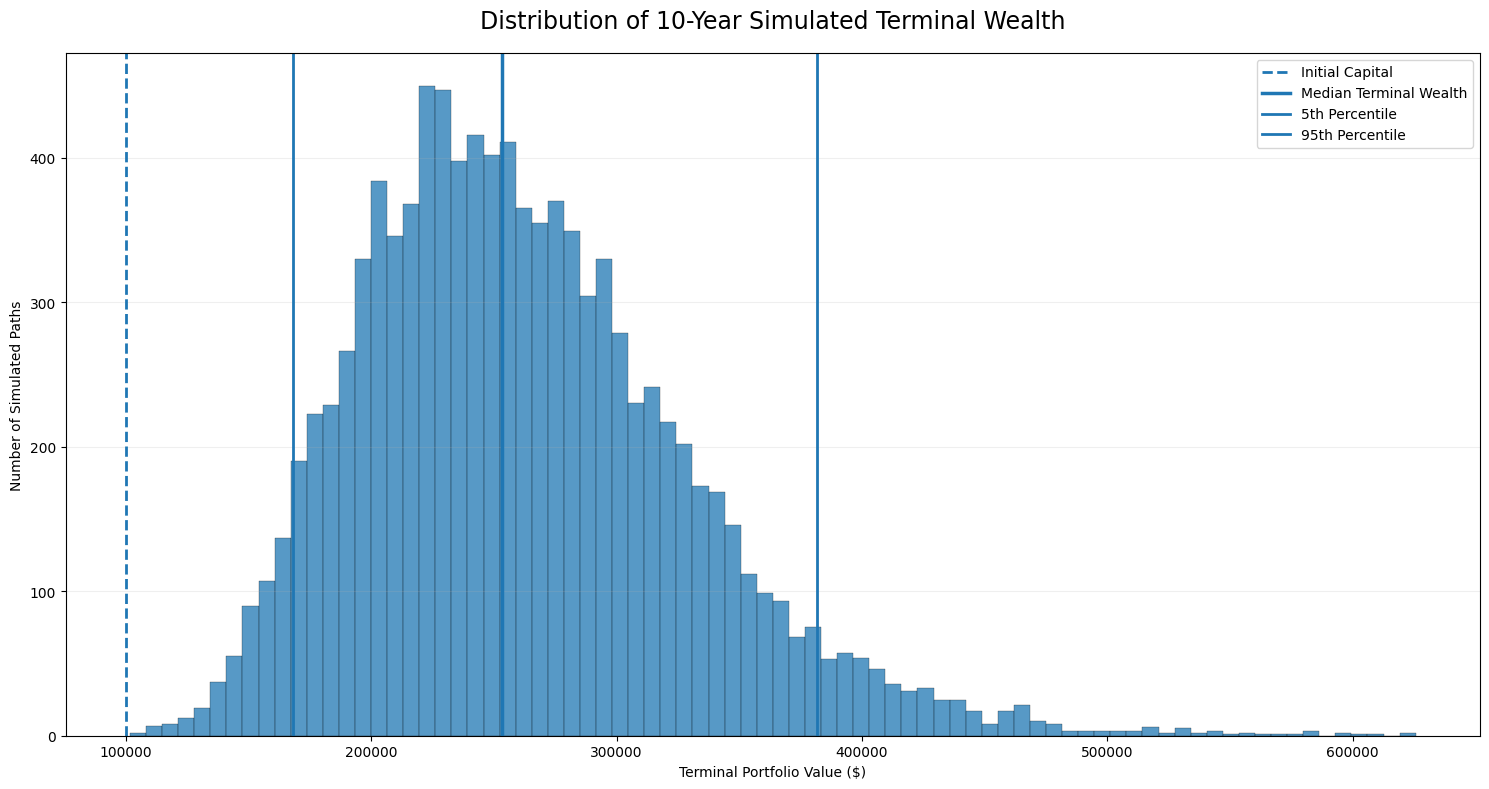

Probability of ending below $100,000: 0.00%
Probability of at least doubling the portfolio: 82.85%


In [21]:
# ============================================================
# CELL 21: TERMINAL WEALTH DISTRIBUTION AND RISK SUMMARY
# ============================================================

terminal_wealth = (
    monte_carlo_wealth_paths[
        :,
        -1,
    ]
)


simulated_cagr = (
    terminal_wealth
    / CONFIG.initial_capital
) ** (
    1.0
    / CONFIG.simulation_years
) - 1.0


terminal_wealth_var = np.percentile(
    terminal_wealth,
    100.0
    * (
        1.0
        - CONFIG.confidence_level
    ),
)


terminal_wealth_expected_shortfall = (
    terminal_wealth[
        terminal_wealth
        <= terminal_wealth_var
    ]
    .mean()
)


probability_of_loss = float(
    np.mean(
        terminal_wealth
        < CONFIG.initial_capital
    )
)


probability_of_doubling = float(
    np.mean(
        terminal_wealth
        >= 2.0
        * CONFIG.initial_capital
    )
)


terminal_wealth_summary = pd.Series(
    {
        "Initial Capital":
            CONFIG.initial_capital,
        "Mean Terminal Wealth":
            terminal_wealth.mean(),
        "Median Terminal Wealth":
            np.median(terminal_wealth),
        "5th Percentile Wealth":
            np.percentile(
                terminal_wealth,
                5,
            ),
        "25th Percentile Wealth":
            np.percentile(
                terminal_wealth,
                25,
            ),
        "75th Percentile Wealth":
            np.percentile(
                terminal_wealth,
                75,
            ),
        "95th Percentile Wealth":
            np.percentile(
                terminal_wealth,
                95,
            ),
        "Expected Shortfall Wealth":
            terminal_wealth_expected_shortfall,
        "Median Simulated CAGR":
            np.median(simulated_cagr),
        "Probability of Loss":
            probability_of_loss,
        "Probability of Doubling":
            probability_of_doubling,
    },
    name="Monte Carlo Result",
)


print("Ten-year terminal-wealth summary:")

display(
    terminal_wealth_summary.to_frame()
)


fig, ax = plt.subplots(
    figsize=(15, 8)
)


ax.hist(
    terminal_wealth,
    bins=80,
    alpha=0.75,
    edgecolor="black",
    linewidth=0.25,
)


ax.axvline(
    CONFIG.initial_capital,
    linestyle="--",
    linewidth=2,
    label="Initial Capital",
)


ax.axvline(
    np.median(terminal_wealth),
    linewidth=2.5,
    label="Median Terminal Wealth",
)


ax.axvline(
    np.percentile(
        terminal_wealth,
        5,
    ),
    linewidth=2,
    label="5th Percentile",
)


ax.axvline(
    np.percentile(
        terminal_wealth,
        95,
    ),
    linewidth=2,
    label="95th Percentile",
)


ax.set_title(
    "Distribution of 10-Year Simulated Terminal Wealth",
    fontsize=17,
    pad=18,
)

ax.set_xlabel(
    "Terminal Portfolio Value ($)"
)

ax.set_ylabel(
    "Number of Simulated Paths"
)

ax.grid(
    True,
    axis="y",
    alpha=0.20,
)

ax.legend()


plt.tight_layout()
plt.show()


print(
    f"Probability of ending below "
    f"${CONFIG.initial_capital:,.0f}: "
    f"{probability_of_loss:.2%}"
)

print(
    "Probability of at least doubling the portfolio: "
    f"{probability_of_doubling:.2%}"
)

### Simulated Drawdown Risk

Maximum drawdown measures the largest percentage decline from a previous
portfolio peak within each simulated path.

This is often easier to understand than volatility because it approximates the
worst temporary loss an investor might experience.

Simulated maximum-drawdown summary:


,Drawdown Result
Mean Maximum Drawdown,-10.06%
Median Maximum Drawdown,-9.43%
25th Percentile,-11.84%
10th Percentile,-14.52%
5th Percentile,-16.31%
Worst Simulated Drawdown,-28.80%


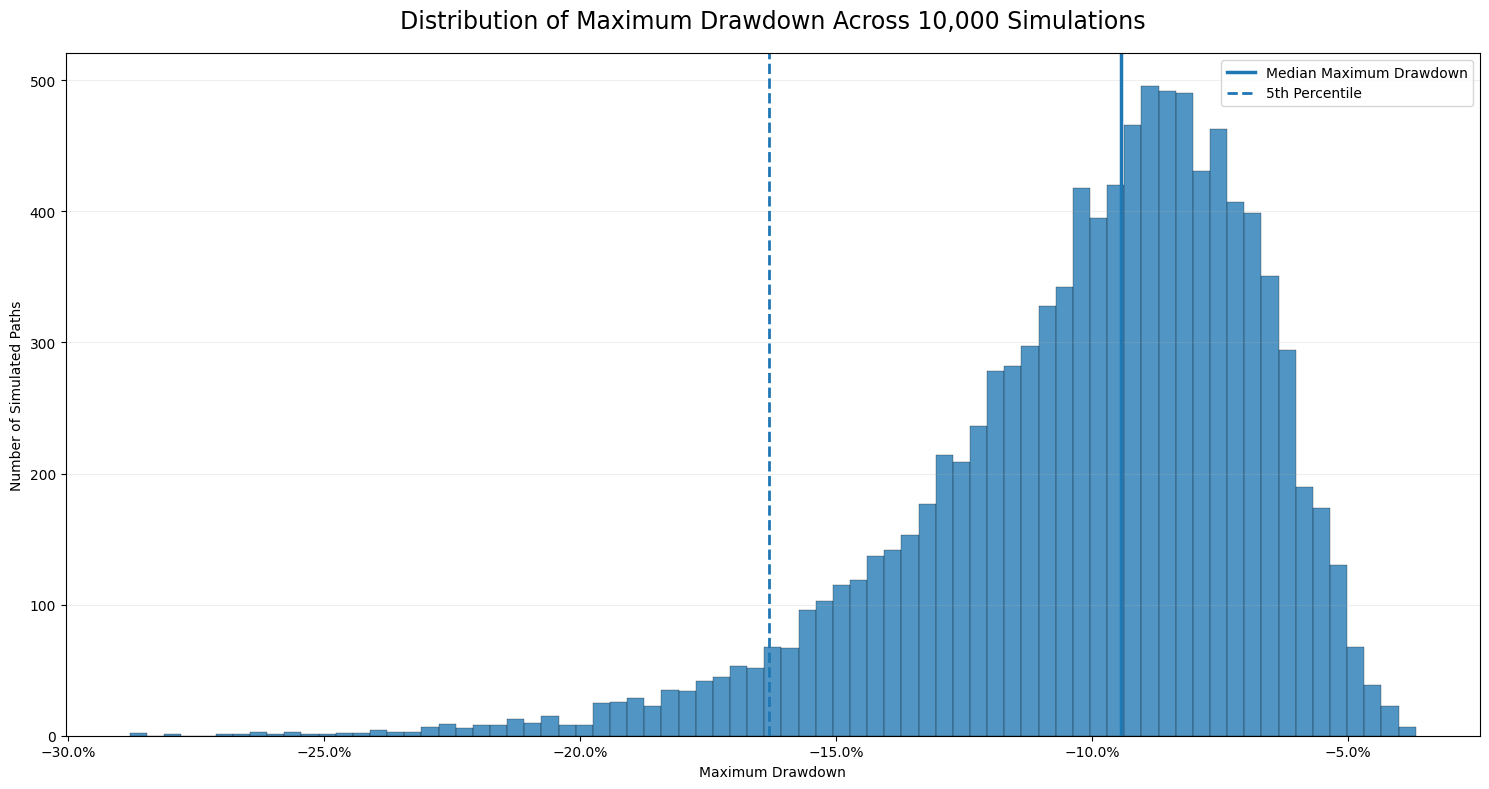

In [22]:
# ============================================================
# CELL 22: SIMULATED MAXIMUM-DRAWDOWN DISTRIBUTION
# ============================================================

running_maximum_wealth = np.maximum.accumulate(
    monte_carlo_wealth_paths,
    axis=1,
)


simulated_drawdowns = (
    monte_carlo_wealth_paths
    / running_maximum_wealth
    - 1.0
)


simulated_maximum_drawdown = (
    simulated_drawdowns.min(
        axis=1
    )
)


drawdown_summary = pd.Series(
    {
        "Mean Maximum Drawdown":
            simulated_maximum_drawdown.mean(),
        "Median Maximum Drawdown":
            np.median(
                simulated_maximum_drawdown
            ),
        "25th Percentile":
            np.percentile(
                simulated_maximum_drawdown,
                25,
            ),
        "10th Percentile":
            np.percentile(
                simulated_maximum_drawdown,
                10,
            ),
        "5th Percentile":
            np.percentile(
                simulated_maximum_drawdown,
                5,
            ),
        "Worst Simulated Drawdown":
            simulated_maximum_drawdown.min(),
    },
    name="Drawdown Result",
)


print("Simulated maximum-drawdown summary:")

display(
    drawdown_summary.to_frame().style.format(
        "{:.2%}"
    )
)


fig, ax = plt.subplots(
    figsize=(15, 8)
)


ax.hist(
    simulated_maximum_drawdown,
    bins=75,
    alpha=0.78,
    edgecolor="black",
    linewidth=0.25,
)


ax.axvline(
    np.median(
        simulated_maximum_drawdown
    ),
    linewidth=2.5,
    label="Median Maximum Drawdown",
)


ax.axvline(
    np.percentile(
        simulated_maximum_drawdown,
        5,
    ),
    linewidth=2,
    linestyle="--",
    label="5th Percentile",
)


ax.set_title(
    "Distribution of Maximum Drawdown Across 10,000 Simulations",
    fontsize=17,
    pad=18,
)

ax.set_xlabel(
    "Maximum Drawdown"
)

ax.set_ylabel(
    "Number of Simulated Paths"
)


ax.xaxis.set_major_formatter(
    PercentFormatter(1.0)
)


ax.grid(
    True,
    axis="y",
    alpha=0.20,
)

ax.legend()


plt.tight_layout()
plt.show()

Risk by investment horizon:


,Years,Probability of Loss,Median Wealth,5th Percentile Wealth,95th Percentile Wealth,Probability of Doubling
Investment Horizon,,,,,,
1 Years,1,12.27%,"$109,725","$96,266","$125,107",0.00%
3 Years,3,2.22%,"$132,261","$105,260","$165,038",0.12%
5 Years,5,0.42%,"$159,410","$119,259","$212,547",9.81%
7 Years,7,0.09%,"$191,485","$135,954","$270,257",41.72%
10 Years,10,0.00%,"$253,415","$168,226","$381,819",82.85%


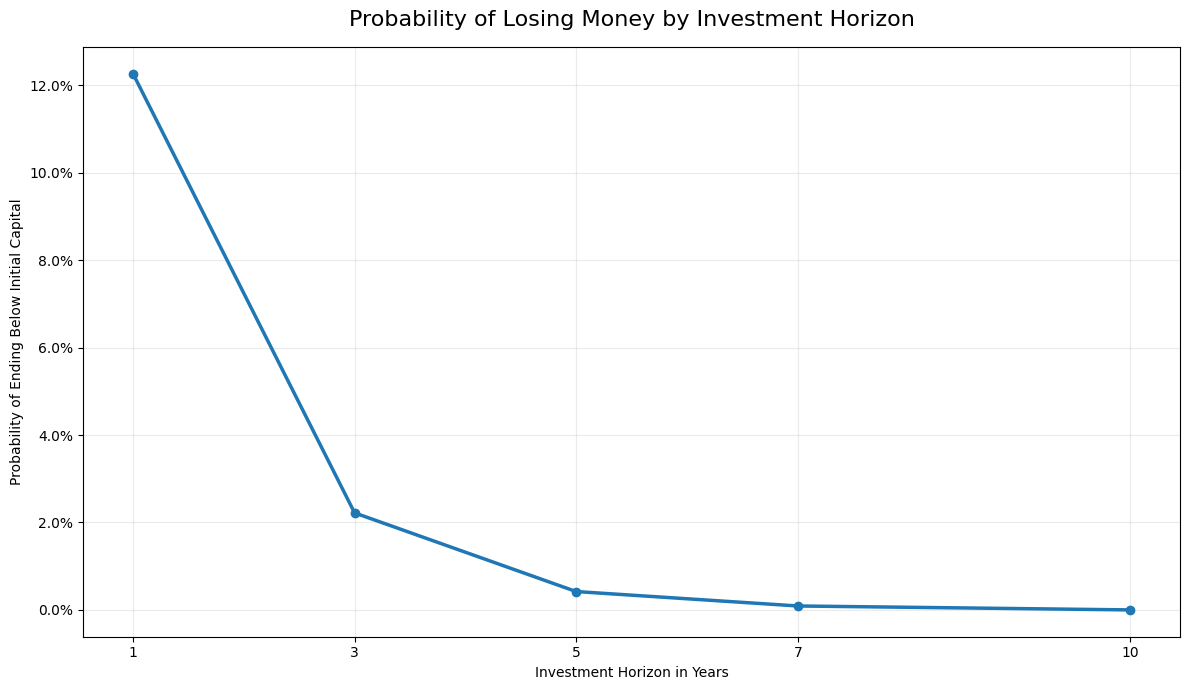

In [23]:
# ============================================================
# CELL 23: HORIZON-BASED LOSS-PROBABILITY ANALYSIS
# ============================================================

HORIZON_YEARS = [
    1,
    3,
    5,
    7,
    10,
]


horizon_records = []


for horizon_years in HORIZON_YEARS:

    month_position = (
        horizon_years
        * CONFIG.months_per_year
    )

    horizon_wealth = (
        monte_carlo_wealth_paths[
            :,
            month_position,
        ]
    )

    horizon_records.append(
        {
            "Investment Horizon":
                f"{horizon_years} Years",
            "Years":
                horizon_years,
            "Probability of Loss":
                np.mean(
                    horizon_wealth
                    < CONFIG.initial_capital
                ),
            "Median Wealth":
                np.median(
                    horizon_wealth
                ),
            "5th Percentile Wealth":
                np.percentile(
                    horizon_wealth,
                    5,
                ),
            "95th Percentile Wealth":
                np.percentile(
                    horizon_wealth,
                    95,
                ),
            "Probability of Doubling":
                np.mean(
                    horizon_wealth
                    >= 2.0
                    * CONFIG.initial_capital
                ),
        }
    )


horizon_risk_table = (
    pd.DataFrame(
        horizon_records
    )
    .set_index(
        "Investment Horizon"
    )
)


print("Risk by investment horizon:")

display(
    horizon_risk_table.style.format(
        {
            "Probability of Loss": "{:.2%}",
            "Median Wealth": "${:,.0f}",
            "5th Percentile Wealth": "${:,.0f}",
            "95th Percentile Wealth": "${:,.0f}",
            "Probability of Doubling": "{:.2%}",
        }
    )
)


fig, ax = plt.subplots(
    figsize=(12, 7)
)


ax.plot(
    horizon_risk_table[
        "Years"
    ],
    horizon_risk_table[
        "Probability of Loss"
    ],
    marker="o",
    linewidth=2.5,
)


ax.set_title(
    "Probability of Losing Money by Investment Horizon",
    fontsize=16,
    pad=15,
)

ax.set_xlabel(
    "Investment Horizon in Years"
)

ax.set_ylabel(
    "Probability of Ending Below Initial Capital"
)


ax.yaxis.set_major_formatter(
    PercentFormatter(1.0)
)


ax.set_xticks(
    HORIZON_YEARS
)

ax.grid(
    True,
    alpha=0.25,
)


plt.tight_layout()
plt.show()

## 6. Model Robustness, Stress Testing, and Risk Surfaces

A parametric Monte Carlo model assumes that future returns follow a statistical
distribution estimated from historical averages and covariances.

A historical block bootstrap takes a different approach. It resamples groups of
actual historical monthly returns, preserving cross-asset relationships and
some short-term market behavior.

This section compares both methods, tests adverse correlation scenarios, and
studies how investment horizon and asset allocation affect downside risk.

In [24]:
# ============================================================
# CELL 24: HISTORICAL BLOCK-BOOTSTRAP SIMULATION
# ============================================================

BOOTSTRAP_BLOCK_MONTHS = 6
BOOTSTRAP_PATHS = min(
    5_000,
    CONFIG.monte_carlo_paths,
)


def generate_block_bootstrap_asset_returns(
    historical_returns: pd.DataFrame,
    number_of_paths: int,
    number_of_months: int,
    block_length: int,
    random_seed: int,
) -> np.ndarray:
    """
    Resample consecutive blocks of historical monthly asset returns.

    Sampling consecutive blocks preserves cross-asset correlation
    and some short-term time dependence found in actual markets.
    """

    historical_array = (
        historical_returns
        .reindex(columns=TICKERS)
        .to_numpy(dtype=float)
    )

    number_of_observations = len(
        historical_array
    )

    if number_of_observations < block_length:
        raise ValueError(
            "The historical dataset is shorter than the block length."
        )

    number_of_blocks = math.ceil(
        number_of_months
        / block_length
    )

    random_generator = np.random.default_rng(
        random_seed
    )

    starting_positions = (
        random_generator.integers(
            low=0,
            high=(
                number_of_observations
                - block_length
                + 1
            ),
            size=(
                number_of_paths,
                number_of_blocks,
            ),
        )
    )

    block_offsets = np.arange(
        block_length
    )

    sampled_indices = (
        starting_positions[:, :, None]
        + block_offsets[None, None, :]
    )

    sampled_indices = (
        sampled_indices
        .reshape(
            number_of_paths,
            -1,
        )[:, :number_of_months]
    )

    return historical_array[
        sampled_indices
    ]


def simulate_rebalanced_portfolio_from_asset_returns(
    simulated_asset_returns: np.ndarray,
    target_weights: np.ndarray,
    initial_capital: float,
    transaction_cost_bps: float,
) -> dict[str, np.ndarray]:
    """
    Simulate portfolio wealth from an existing asset-return cube.

    Expected input shape:
    paths × months × assets
    """

    number_of_paths = (
        simulated_asset_returns.shape[0]
    )

    number_of_months = (
        simulated_asset_returns.shape[1]
    )

    number_of_assets = (
        simulated_asset_returns.shape[2]
    )

    target_weights = np.asarray(
        target_weights,
        dtype=float,
    )

    if len(target_weights) != number_of_assets:
        raise ValueError(
            "Weight vector does not match the simulated assets."
        )

    if not np.isclose(
        target_weights.sum(),
        1.0,
    ):
        raise ValueError(
            "Target weights must sum to 100%."
        )

    wealth_paths = np.empty(
        (
            number_of_paths,
            number_of_months + 1,
        ),
        dtype=float,
    )

    one_way_turnover = np.zeros(
        (
            number_of_paths,
            number_of_months,
        ),
        dtype=float,
    )

    transaction_costs = np.zeros(
        (
            number_of_paths,
            number_of_months,
        ),
        dtype=float,
    )

    wealth_paths[:, 0] = initial_capital

    transaction_cost_rate = (
        transaction_cost_bps
        / 10_000.0
    )

    for month_position in range(
        number_of_months
    ):

        beginning_wealth = wealth_paths[
            :,
            month_position,
        ]

        month_asset_returns = (
            simulated_asset_returns[
                :,
                month_position,
                :,
            ]
        )

        ending_asset_values = (
            beginning_wealth[:, None]
            * target_weights[None, :]
            * (
                1.0
                + month_asset_returns
            )
        )

        pre_rebalance_wealth = (
            ending_asset_values.sum(
                axis=1
            )
        )

        if (
            pre_rebalance_wealth <= 0
        ).any():
            raise RuntimeError(
                "A bootstrap path reached a nonpositive value."
            )

        drifted_weights = (
            ending_asset_values
            / pre_rebalance_wealth[:, None]
        )

        gross_turnover = np.abs(
            target_weights[None, :]
            - drifted_weights
        ).sum(axis=1)

        one_way_turnover[
            :,
            month_position,
        ] = (
            gross_turnover / 2.0
        )

        if month_position < number_of_months - 1:

            monthly_cost = (
                pre_rebalance_wealth
                * gross_turnover
                * transaction_cost_rate
            )

        else:
            monthly_cost = np.zeros(
                number_of_paths
            )

        transaction_costs[
            :,
            month_position,
        ] = monthly_cost

        wealth_paths[
            :,
            month_position + 1,
        ] = (
            pre_rebalance_wealth
            - monthly_cost
        )

    return {
        "wealth_paths": wealth_paths,
        "one_way_turnover": one_way_turnover,
        "transaction_costs": transaction_costs,
    }


bootstrap_asset_returns = (
    generate_block_bootstrap_asset_returns(
        historical_returns=
            monthly_simple_returns,
        number_of_paths=
            BOOTSTRAP_PATHS,
        number_of_months=
            SIMULATION_MONTHS,
        block_length=
            BOOTSTRAP_BLOCK_MONTHS,
        random_seed=
            RANDOM_SEED + 100,
    )
)


BOOTSTRAP_OUTPUT = (
    simulate_rebalanced_portfolio_from_asset_returns(
        simulated_asset_returns=
            bootstrap_asset_returns,
        target_weights=
            maximum_sharpe_weights,
        initial_capital=
            CONFIG.initial_capital,
        transaction_cost_bps=
            CONFIG.transaction_cost_bps,
    )
)


bootstrap_wealth_paths = (
    BOOTSTRAP_OUTPUT[
        "wealth_paths"
    ]
)


bootstrap_terminal_wealth = (
    bootstrap_wealth_paths[
        :,
        -1,
    ]
)


assert bootstrap_wealth_paths.shape == (
    BOOTSTRAP_PATHS,
    SIMULATION_MONTHS + 1,
)

assert np.isfinite(
    bootstrap_wealth_paths
).all()

assert (
    bootstrap_wealth_paths > 0
).all()


print("Historical block-bootstrap completed successfully.")
print(f"Bootstrap paths: {BOOTSTRAP_PATHS:,}")
print(
    f"Block length: "
    f"{BOOTSTRAP_BLOCK_MONTHS} months"
)
print(
    "Median terminal wealth: "
    f"${np.median(bootstrap_terminal_wealth):,.2f}"
)

Historical block-bootstrap completed successfully.
Bootstrap paths: 5,000
Block length: 6 months
Median terminal wealth: $254,586.37


Simulation-model comparison:


,Mean Terminal Wealth,Median Terminal Wealth,5th Percentile Wealth,95th Percentile Wealth,Probability of Loss,Median CAGR,Median Maximum Drawdown,5th Percentile Drawdown
Parametric Monte Carlo,"$261,676","$253,415","$168,226","$381,819",0.00%,9.74%,-9.43%,-16.31%
Historical Block Bootstrap,"$260,574","$254,586","$168,913","$373,518",0.00%,9.80%,-10.42%,-19.07%


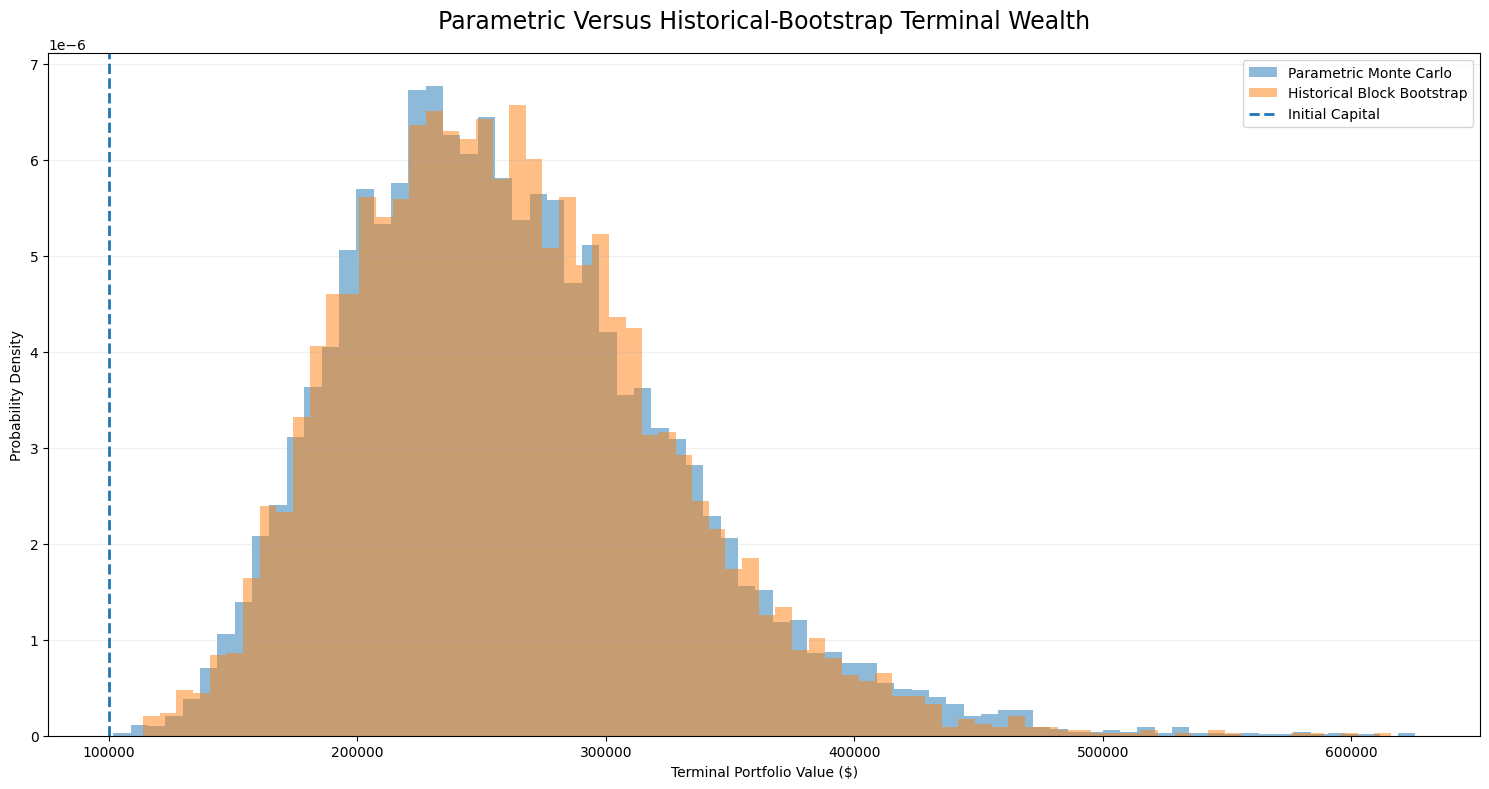

In [25]:
# ============================================================
# CELL 25: PARAMETRIC VERSUS BOOTSTRAP COMPARISON
# ============================================================

def summarize_terminal_distribution(
    model_name: str,
    wealth_paths: np.ndarray,
) -> pd.Series:
    """Summarize the terminal and drawdown distribution."""

    terminal_values = wealth_paths[
        :,
        -1,
    ]

    running_peaks = np.maximum.accumulate(
        wealth_paths,
        axis=1,
    )

    drawdowns = (
        wealth_paths
        / running_peaks
        - 1.0
    )

    maximum_drawdowns = drawdowns.min(
        axis=1
    )

    simulated_growth_rates = (
        terminal_values
        / CONFIG.initial_capital
    ) ** (
        1.0
        / CONFIG.simulation_years
    ) - 1.0

    return pd.Series(
        {
            "Mean Terminal Wealth":
                terminal_values.mean(),
            "Median Terminal Wealth":
                np.median(terminal_values),
            "5th Percentile Wealth":
                np.percentile(
                    terminal_values,
                    5,
                ),
            "95th Percentile Wealth":
                np.percentile(
                    terminal_values,
                    95,
                ),
            "Probability of Loss":
                np.mean(
                    terminal_values
                    < CONFIG.initial_capital
                ),
            "Median CAGR":
                np.median(
                    simulated_growth_rates
                ),
            "Median Maximum Drawdown":
                np.median(
                    maximum_drawdowns
                ),
            "5th Percentile Drawdown":
                np.percentile(
                    maximum_drawdowns,
                    5,
                ),
        },
        name=model_name,
    )


simulation_model_comparison = pd.concat(
    [
        summarize_terminal_distribution(
            model_name="Parametric Monte Carlo",
            wealth_paths=
                monte_carlo_wealth_paths,
        ),
        summarize_terminal_distribution(
            model_name="Historical Block Bootstrap",
            wealth_paths=
                bootstrap_wealth_paths,
        ),
    ],
    axis=1,
).T


print("Simulation-model comparison:")

display(
    simulation_model_comparison.style.format(
        {
            "Mean Terminal Wealth": "${:,.0f}",
            "Median Terminal Wealth": "${:,.0f}",
            "5th Percentile Wealth": "${:,.0f}",
            "95th Percentile Wealth": "${:,.0f}",
            "Probability of Loss": "{:.2%}",
            "Median CAGR": "{:.2%}",
            "Median Maximum Drawdown": "{:.2%}",
            "5th Percentile Drawdown": "{:.2%}",
        }
    )
)


fig, ax = plt.subplots(
    figsize=(15, 8)
)


ax.hist(
    terminal_wealth,
    bins=75,
    density=True,
    alpha=0.50,
    label="Parametric Monte Carlo",
)


ax.hist(
    bootstrap_terminal_wealth,
    bins=75,
    density=True,
    alpha=0.50,
    label="Historical Block Bootstrap",
)


ax.axvline(
    CONFIG.initial_capital,
    linestyle="--",
    linewidth=2,
    label="Initial Capital",
)


ax.set_title(
    "Parametric Versus Historical-Bootstrap Terminal Wealth",
    fontsize=17,
    pad=18,
)

ax.set_xlabel(
    "Terminal Portfolio Value ($)"
)

ax.set_ylabel(
    "Probability Density"
)

ax.grid(
    True,
    axis="y",
    alpha=0.20,
)

ax.legend()


plt.tight_layout()
plt.show()

Five-year stress-test summary:


,Median Terminal Wealth,5th Percentile Wealth,Probability of Loss,Median Maximum Drawdown
Scenario,,,,
Baseline,"$159,332","$118,605",0.38%,-7.60%
Elevated Correlation,"$159,216","$115,635",0.88%,-8.85%
Crisis Correlation,"$159,256","$111,782",1.47%,-9.99%
Crisis + Recession Shock,"$139,859","$99,504",5.42%,-11.79%


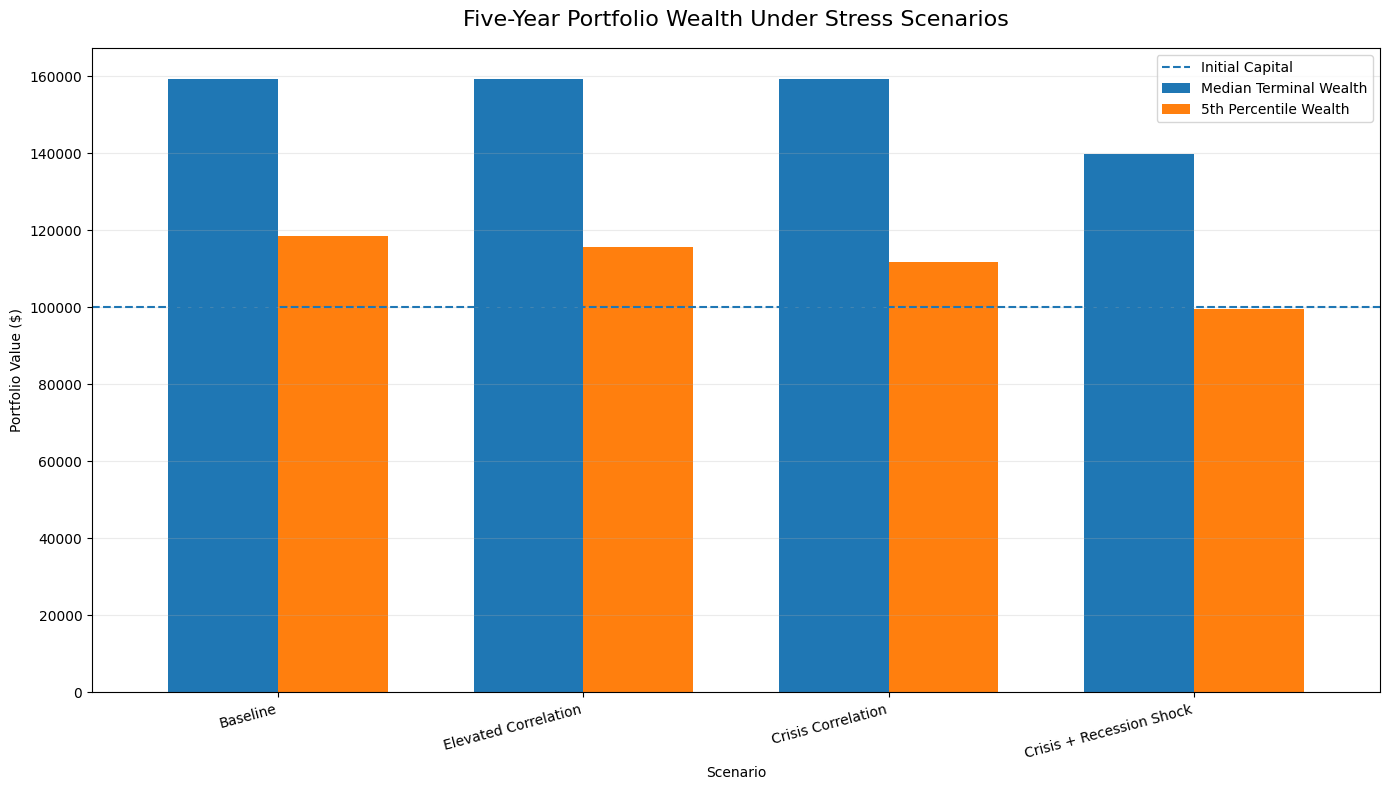

In [26]:
# ============================================================
# CELL 26: CRISIS-CORRELATION AND RETURN STRESS TESTS
# ============================================================

STRESS_PATHS = 4_000
STRESS_YEARS = 5
STRESS_MONTHS = (
    STRESS_YEARS
    * CONFIG.months_per_year
)


# Convert the covariance DataFrame into a NumPy array before
# performing NumPy matrix operations.
monthly_covariance_array = (
    monthly_log_covariance
    .reindex(
        index=TICKERS,
        columns=TICKERS,
    )
    .to_numpy(dtype=float)
)


base_monthly_volatility = np.sqrt(
    np.diag(monthly_covariance_array)
)


base_monthly_correlation = (
    monthly_covariance_array
    / np.outer(
        base_monthly_volatility,
        base_monthly_volatility,
    )
)


base_monthly_correlation = np.clip(
    base_monthly_correlation,
    -1.0,
    1.0,
)


# This now works because base_monthly_correlation is a NumPy array.
np.fill_diagonal(
    base_monthly_correlation,
    1.0,
)


RISKY_ASSETS = [
    "SPY",
    "QQQ",
    "IWM",
    "EFA",
    "EEM",
    "VNQ",
]


def create_stressed_covariance(
    correlation_blend: float,
) -> pd.DataFrame:
    """
    Blend historical correlations toward perfect positive correlation.

    A larger correlation_blend represents diversification becoming
    less effective during a market crisis.
    """

    if not 0.0 <= correlation_blend <= 1.0:
        raise ValueError(
            "correlation_blend must be between 0 and 1."
        )

    stressed_correlation = (
        (
            1.0
            - correlation_blend
        )
        * base_monthly_correlation
        + correlation_blend
        * np.ones_like(
            base_monthly_correlation
        )
    )

    np.fill_diagonal(
        stressed_correlation,
        1.0,
    )

    stressed_covariance = (
        np.outer(
            base_monthly_volatility,
            base_monthly_volatility,
        )
        * stressed_correlation
    )

    stressed_covariance = (
        make_positive_semidefinite(
            stressed_covariance
        )
    )

    return pd.DataFrame(
        stressed_covariance,
        index=TICKERS,
        columns=TICKERS,
    )


stress_scenarios = {
    "Baseline": {
        "Correlation Blend": 0.00,
        "Risky-Asset Monthly Mean Shock": 0.000,
    },
    "Elevated Correlation": {
        "Correlation Blend": 0.25,
        "Risky-Asset Monthly Mean Shock": 0.000,
    },
    "Crisis Correlation": {
        "Correlation Blend": 0.50,
        "Risky-Asset Monthly Mean Shock": 0.000,
    },
    "Crisis + Recession Shock": {
        "Correlation Blend": 0.50,
        "Risky-Asset Monthly Mean Shock": -0.005,
    },
}


stress_results = []
stress_terminal_distributions = {}


for scenario_number, (
    scenario_name,
    scenario_settings,
) in enumerate(
    stress_scenarios.items()
):

    stressed_mean = (
        monthly_log_mean
        .reindex(TICKERS)
        .copy()
    )

    stressed_mean.loc[
        RISKY_ASSETS
    ] += scenario_settings[
        "Risky-Asset Monthly Mean Shock"
    ]

    stressed_covariance = (
        create_stressed_covariance(
            correlation_blend=
                scenario_settings[
                    "Correlation Blend"
                ]
        )
    )

    scenario_output = (
        simulate_monthly_rebalanced_portfolio(
            target_weights=
                maximum_sharpe_weights,
            monthly_log_return_mean=
                stressed_mean,
            monthly_log_return_covariance=
                stressed_covariance,
            initial_capital=
                CONFIG.initial_capital,
            number_of_paths=
                STRESS_PATHS,
            number_of_months=
                STRESS_MONTHS,
            transaction_cost_bps=
                CONFIG.transaction_cost_bps,
            random_seed=
                RANDOM_SEED
                + 500
                + scenario_number,
        )
    )

    scenario_wealth_paths = (
        scenario_output[
            "wealth_paths"
        ]
    )

    scenario_terminal_wealth = (
        scenario_wealth_paths[
            :,
            -1,
        ]
    )

    scenario_running_peaks = (
        np.maximum.accumulate(
            scenario_wealth_paths,
            axis=1,
        )
    )

    scenario_max_drawdowns = (
        scenario_wealth_paths
        / scenario_running_peaks
        - 1.0
    ).min(axis=1)

    stress_terminal_distributions[
        scenario_name
    ] = scenario_terminal_wealth

    stress_results.append(
        {
            "Scenario": scenario_name,
            "Median Terminal Wealth":
                np.median(
                    scenario_terminal_wealth
                ),
            "5th Percentile Wealth":
                np.percentile(
                    scenario_terminal_wealth,
                    5,
                ),
            "Probability of Loss":
                np.mean(
                    scenario_terminal_wealth
                    < CONFIG.initial_capital
                ),
            "Median Maximum Drawdown":
                np.median(
                    scenario_max_drawdowns
                ),
        }
    )


stress_test_summary = (
    pd.DataFrame(
        stress_results
    )
    .set_index(
        "Scenario"
    )
)


print("Five-year stress-test summary:")

display(
    stress_test_summary.style.format(
        {
            "Median Terminal Wealth": "${:,.0f}",
            "5th Percentile Wealth": "${:,.0f}",
            "Probability of Loss": "{:.2%}",
            "Median Maximum Drawdown": "{:.2%}",
        }
    )
)


ax = stress_test_summary[
    [
        "Median Terminal Wealth",
        "5th Percentile Wealth",
    ]
].plot(
    kind="bar",
    figsize=(14, 8),
    width=0.72,
)


ax.axhline(
    CONFIG.initial_capital,
    linestyle="--",
    linewidth=1.5,
    label="Initial Capital",
)


ax.set_title(
    "Five-Year Portfolio Wealth Under Stress Scenarios",
    fontsize=16,
    pad=16,
)

ax.set_xlabel(
    "Scenario"
)

ax.set_ylabel(
    "Portfolio Value ($)"
)

ax.grid(
    True,
    axis="y",
    alpha=0.25,
)

ax.legend()


plt.xticks(
    rotation=15,
    ha="right",
)

plt.tight_layout()
plt.show()

In [27]:
# ============================================================
# CELL 27: ALLOCATION–HORIZON LOSS-PROBABILITY GRID
# ============================================================

SURFACE_PATHS = 2_500
SURFACE_MONTHS = (
    10
    * CONFIG.months_per_year
)


def simulate_correlated_asset_returns(
    monthly_mean: pd.Series,
    monthly_covariance: pd.DataFrame,
    number_of_paths: int,
    number_of_months: int,
    random_seed: int,
) -> np.ndarray:
    """Generate a reusable cube of correlated monthly returns."""

    covariance_array = (
        monthly_covariance
        .reindex(
            index=TICKERS,
            columns=TICKERS,
        )
        .to_numpy(dtype=float)
    )

    repaired_covariance = (
        make_positive_semidefinite(
            covariance_array
        )
    )

    cholesky_factor = np.linalg.cholesky(
        repaired_covariance
    )

    mean_vector = (
        monthly_mean
        .reindex(TICKERS)
        .to_numpy(dtype=float)
    )

    random_generator = np.random.default_rng(
        random_seed
    )

    independent_shocks = (
        random_generator.standard_normal(
            size=(
                number_of_paths,
                number_of_months,
                len(TICKERS),
            )
        )
    )

    correlated_log_returns = (
        mean_vector[None, None, :]
        + independent_shocks
        @ cholesky_factor.T
    )

    return np.expm1(
        correlated_log_returns
    )


surface_asset_returns = (
    simulate_correlated_asset_returns(
        monthly_mean=
            monthly_log_mean,
        monthly_covariance=
            monthly_log_covariance,
        number_of_paths=
            SURFACE_PATHS,
        number_of_months=
            SURFACE_MONTHS,
        random_seed=
            RANDOM_SEED + 1_000,
    )
)


EQUITY_SLEEVE = [
    "SPY",
    "QQQ",
    "IWM",
    "EFA",
    "EEM",
    "VNQ",
]


DEFENSIVE_SLEEVE = [
    "TLT",
    "LQD",
    "GLD",
    "BIL",
]


EQUITY_ALLOCATIONS = np.linspace(
    0.0,
    1.0,
    11,
)


SURFACE_HORIZONS = np.arange(
    1,
    11,
)


loss_probability_surface = np.zeros(
    (
        len(SURFACE_HORIZONS),
        len(EQUITY_ALLOCATIONS),
    )
)


median_wealth_surface = np.zeros_like(
    loss_probability_surface
)


for allocation_position, equity_allocation in enumerate(
    EQUITY_ALLOCATIONS
):

    allocation_weights = np.zeros(
        len(TICKERS)
    )

    for ticker in EQUITY_SLEEVE:

        ticker_position = TICKERS.index(
            ticker
        )

        allocation_weights[
            ticker_position
        ] = (
            equity_allocation
            / len(EQUITY_SLEEVE)
        )

    for ticker in DEFENSIVE_SLEEVE:

        ticker_position = TICKERS.index(
            ticker
        )

        allocation_weights[
            ticker_position
        ] = (
            (
                1.0
                - equity_allocation
            )
            / len(DEFENSIVE_SLEEVE)
        )

    allocation_output = (
        simulate_rebalanced_portfolio_from_asset_returns(
            simulated_asset_returns=
                surface_asset_returns,
            target_weights=
                allocation_weights,
            initial_capital=
                CONFIG.initial_capital,
            transaction_cost_bps=
                CONFIG.transaction_cost_bps,
        )
    )

    allocation_wealth_paths = (
        allocation_output[
            "wealth_paths"
        ]
    )

    for horizon_position, horizon_years in enumerate(
        SURFACE_HORIZONS
    ):

        month_position = (
            horizon_years
            * CONFIG.months_per_year
        )

        horizon_values = (
            allocation_wealth_paths[
                :,
                month_position,
            ]
        )

        loss_probability_surface[
            horizon_position,
            allocation_position,
        ] = np.mean(
            horizon_values
            < CONFIG.initial_capital
        )

        median_wealth_surface[
            horizon_position,
            allocation_position,
        ] = np.median(
            horizon_values
        )


print("Allocation–horizon risk grid created.")
print(
    f"Equity allocations tested: "
    f"{len(EQUITY_ALLOCATIONS)}"
)
print(
    f"Investment horizons tested: "
    f"{len(SURFACE_HORIZONS)}"
)

Allocation–horizon risk grid created.
Equity allocations tested: 11
Investment horizons tested: 10


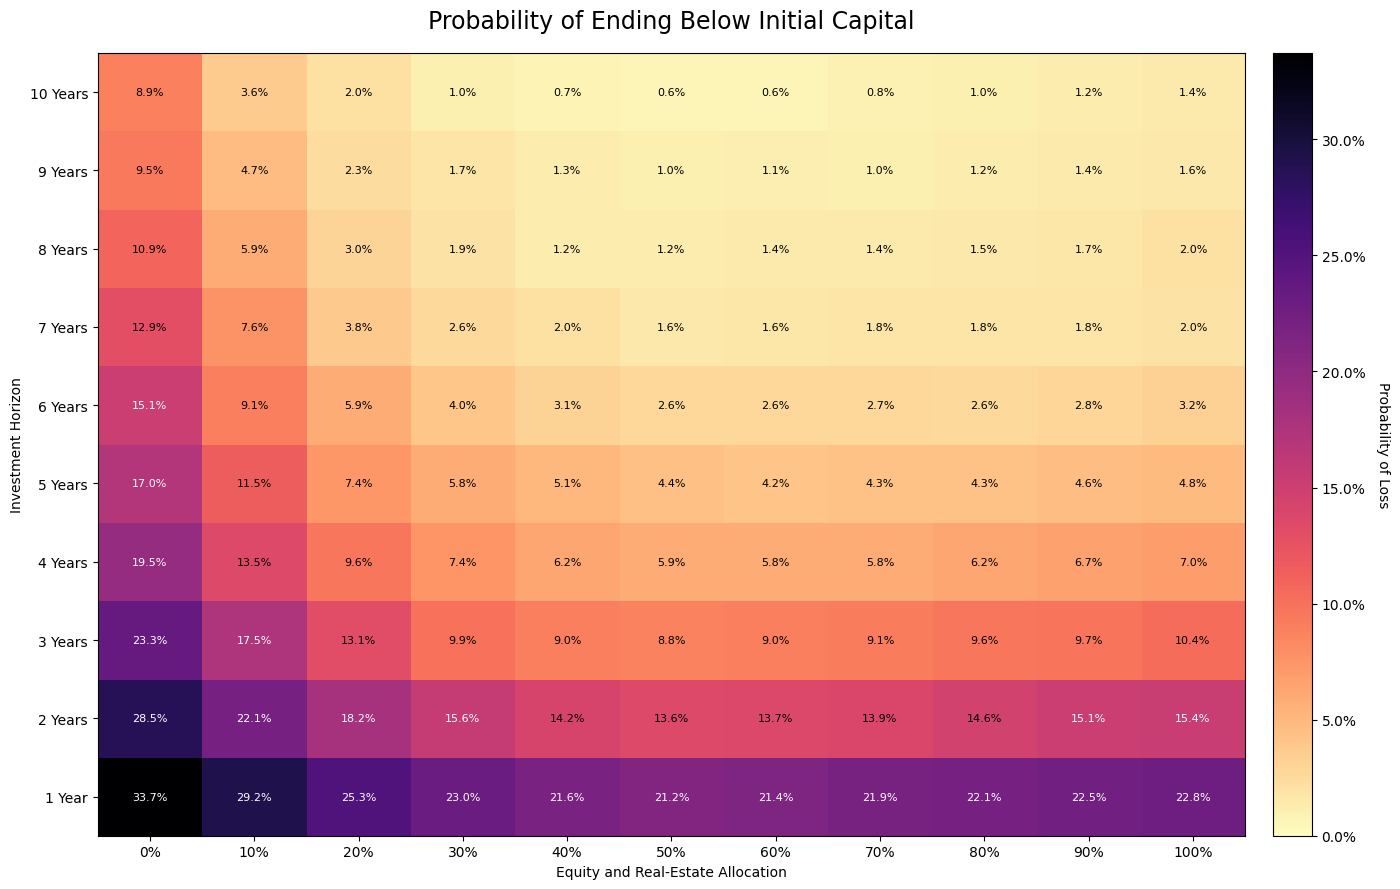

In [28]:
# ============================================================
# CELL 28: PROBABILITY-OF-LOSS HEATMAP
# ============================================================

fig, ax = plt.subplots(
    figsize=(15, 9)
)


loss_heatmap = ax.imshow(
    loss_probability_surface,
    origin="lower",
    aspect="auto",
    cmap="magma_r",
    vmin=0.0,
    vmax=max(
        0.30,
        loss_probability_surface.max(),
    ),
)


ax.set_title(
    "Probability of Ending Below Initial Capital",
    fontsize=17,
    pad=18,
)


ax.set_xlabel(
    "Equity and Real-Estate Allocation"
)

ax.set_ylabel(
    "Investment Horizon"
)


ax.set_xticks(
    range(
        len(EQUITY_ALLOCATIONS)
    )
)

ax.set_xticklabels(
    [
        f"{allocation:.0%}"
        for allocation
        in EQUITY_ALLOCATIONS
    ]
)


ax.set_yticks(
    range(
        len(SURFACE_HORIZONS)
    )
)

ax.set_yticklabels(
    [
        f"{year} Year"
        if year == 1
        else f"{year} Years"
        for year
        in SURFACE_HORIZONS
    ]
)


for row_position in range(
    loss_probability_surface.shape[0]
):

    for column_position in range(
        loss_probability_surface.shape[1]
    ):

        probability_value = (
            loss_probability_surface[
                row_position,
                column_position,
            ]
        )

        ax.text(
            column_position,
            row_position,
            f"{probability_value:.1%}",
            ha="center",
            va="center",
            fontsize=8,
            color=(
                "white"
                if probability_value > 0.15
                else "black"
            ),
        )


colorbar = fig.colorbar(
    loss_heatmap,
    ax=ax,
    pad=0.02,
)

colorbar.set_label(
    "Probability of Loss",
    rotation=270,
    labelpad=18,
)

colorbar.ax.yaxis.set_major_formatter(
    PercentFormatter(1.0)
)


plt.tight_layout()
plt.show()

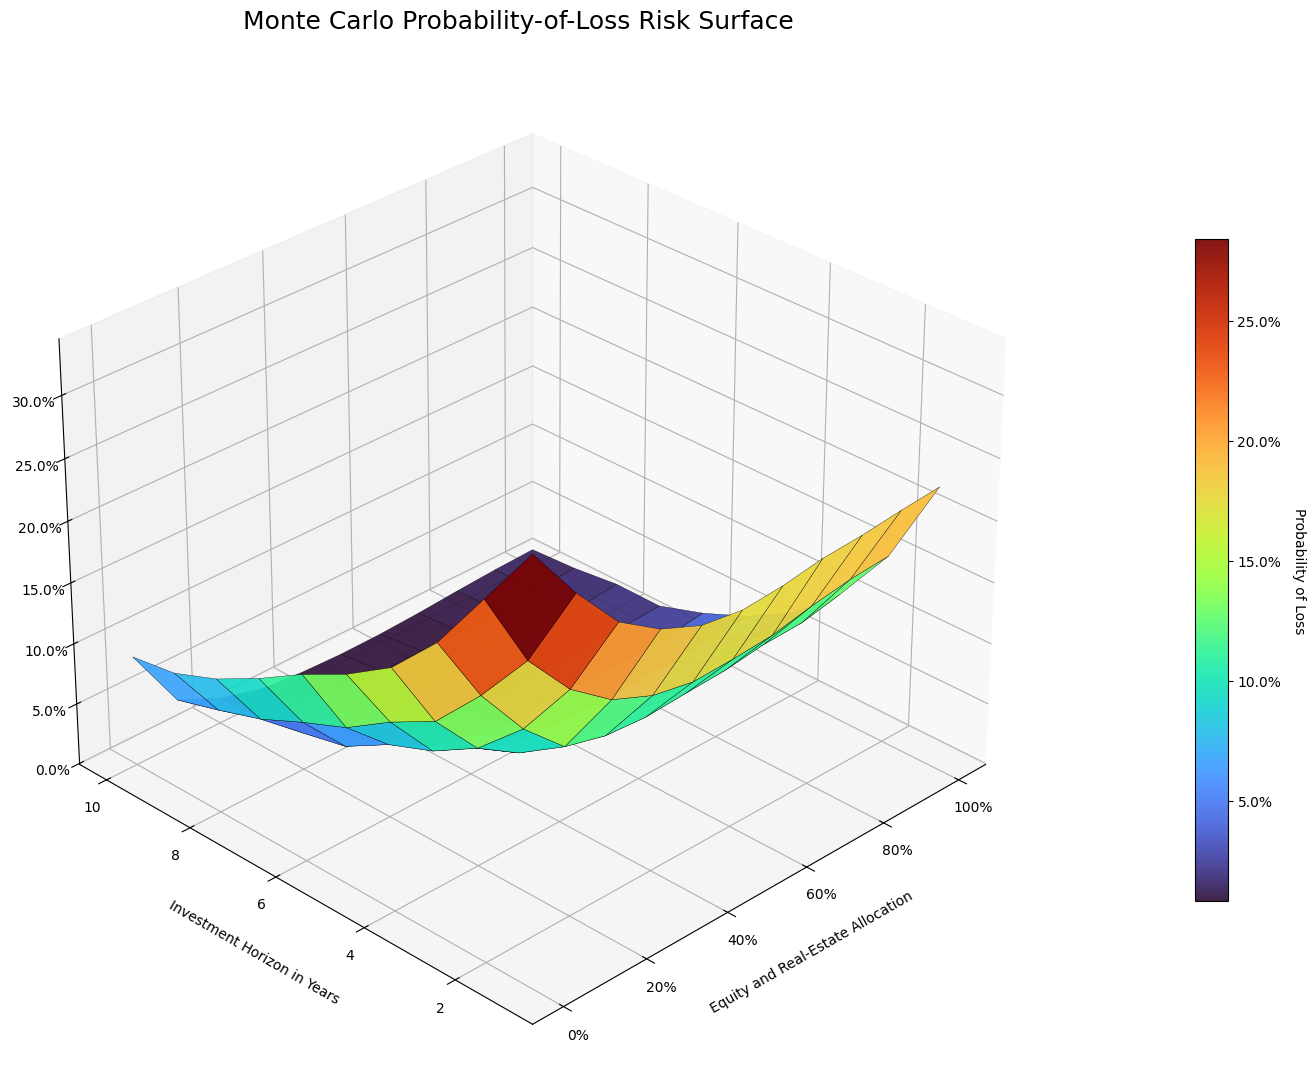

In [29]:
# ============================================================
# CELL 29: THREE-DIMENSIONAL RISK SURFACE
# ============================================================

equity_grid, horizon_grid = np.meshgrid(
    EQUITY_ALLOCATIONS,
    SURFACE_HORIZONS,
)


fig = plt.figure(
    figsize=(17, 11)
)


ax = fig.add_subplot(
    111,
    projection="3d",
)


risk_surface = ax.plot_surface(
    equity_grid,
    horizon_grid,
    loss_probability_surface,
    cmap=cm.turbo,
    linewidth=0.25,
    edgecolor="black",
    antialiased=True,
    alpha=0.92,
)


ax.set_title(
    "Monte Carlo Probability-of-Loss Risk Surface",
    fontsize=18,
    pad=24,
)


ax.set_xlabel(
    "Equity and Real-Estate Allocation",
    labelpad=14,
)

ax.set_ylabel(
    "Investment Horizon in Years",
    labelpad=14,
)

ax.set_zlabel(
    "Probability of Loss",
    labelpad=14,
)


ax.xaxis.set_major_formatter(
    PercentFormatter(1.0)
)

ax.zaxis.set_major_formatter(
    PercentFormatter(1.0)
)


ax.view_init(
    elev=30,
    azim=225,
)


colorbar = fig.colorbar(
    risk_surface,
    ax=ax,
    shrink=0.65,
    pad=0.10,
)

colorbar.set_label(
    "Probability of Loss",
    rotation=270,
    labelpad=18,
)

colorbar.ax.yaxis.set_major_formatter(
    PercentFormatter(1.0)
)


plt.tight_layout()
plt.show()


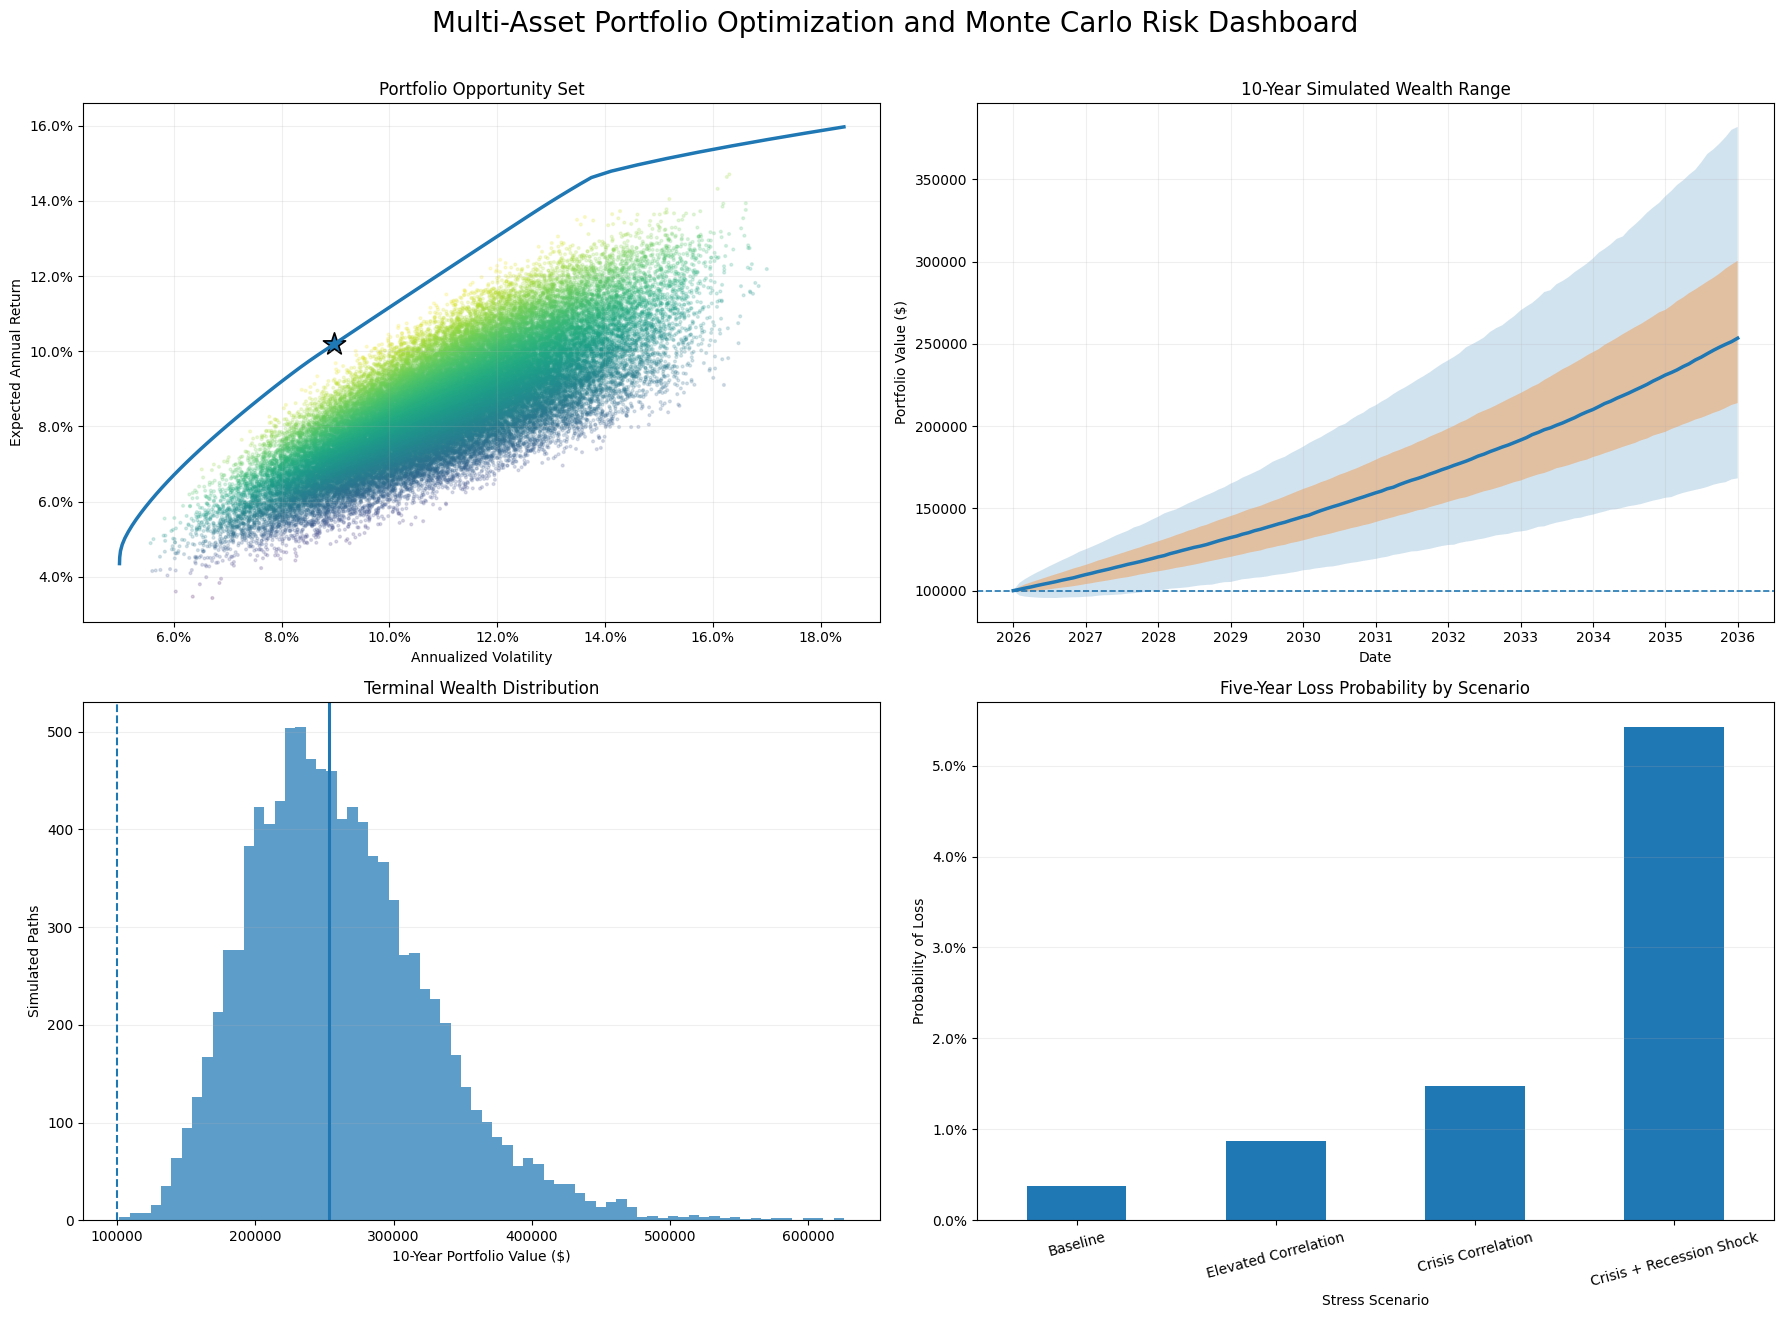

In [30]:
# ============================================================
# CELL 30: EXECUTIVE PORTFOLIO-RISK DASHBOARD
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(18, 13),
)


# ------------------------------------------------------------
# Panel 1: Efficient frontier
# ------------------------------------------------------------
axes[0, 0].scatter(
    random_portfolio_results[
        "Volatility"
    ],
    random_portfolio_results[
        "Expected Return"
    ],
    c=random_portfolio_results[
        "Sharpe Ratio"
    ],
    cmap="viridis",
    s=4,
    alpha=0.18,
)

axes[0, 0].plot(
    efficient_frontier[
        "Volatility"
    ],
    efficient_frontier[
        "Expected Return"
    ],
    linewidth=2.5,
)

axes[0, 0].scatter(
    maximum_sharpe_volatility,
    maximum_sharpe_return,
    marker="*",
    s=280,
    edgecolor="black",
    linewidth=1.2,
)

axes[0, 0].set_title(
    "Portfolio Opportunity Set"
)

axes[0, 0].set_xlabel(
    "Annualized Volatility"
)

axes[0, 0].set_ylabel(
    "Expected Annual Return"
)

axes[0, 0].xaxis.set_major_formatter(
    PercentFormatter(1.0)
)

axes[0, 0].yaxis.set_major_formatter(
    PercentFormatter(1.0)
)

axes[0, 0].grid(
    True,
    alpha=0.20,
)


# ------------------------------------------------------------
# Panel 2: Monte Carlo fan chart
# ------------------------------------------------------------
axes[0, 1].fill_between(
    simulation_dates,
    percentile_5,
    percentile_95,
    alpha=0.20,
)

axes[0, 1].fill_between(
    simulation_dates,
    percentile_25,
    percentile_75,
    alpha=0.35,
)

axes[0, 1].plot(
    simulation_dates,
    percentile_50,
    linewidth=2.5,
)

axes[0, 1].axhline(
    CONFIG.initial_capital,
    linestyle="--",
    linewidth=1.2,
)

axes[0, 1].set_title(
    "10-Year Simulated Wealth Range"
)

axes[0, 1].set_xlabel(
    "Date"
)

axes[0, 1].set_ylabel(
    "Portfolio Value ($)"
)

axes[0, 1].grid(
    True,
    alpha=0.20,
)


# ------------------------------------------------------------
# Panel 3: Terminal wealth
# ------------------------------------------------------------
axes[1, 0].hist(
    terminal_wealth,
    bins=70,
    alpha=0.72,
)

axes[1, 0].axvline(
    CONFIG.initial_capital,
    linestyle="--",
    linewidth=1.5,
)

axes[1, 0].axvline(
    np.median(
        terminal_wealth
    ),
    linewidth=2.2,
)

axes[1, 0].set_title(
    "Terminal Wealth Distribution"
)

axes[1, 0].set_xlabel(
    "10-Year Portfolio Value ($)"
)

axes[1, 0].set_ylabel(
    "Simulated Paths"
)

axes[1, 0].grid(
    True,
    axis="y",
    alpha=0.20,
)


# ------------------------------------------------------------
# Panel 4: Stress tests
# ------------------------------------------------------------
stress_test_summary[
    "Probability of Loss"
].plot(
    kind="bar",
    ax=axes[1, 1],
)


axes[1, 1].set_title(
    "Five-Year Loss Probability by Scenario"
)

axes[1, 1].set_xlabel(
    "Stress Scenario"
)

axes[1, 1].set_ylabel(
    "Probability of Loss"
)

axes[1, 1].yaxis.set_major_formatter(
    PercentFormatter(1.0)
)

axes[1, 1].tick_params(
    axis="x",
    rotation=15,
)

axes[1, 1].grid(
    True,
    axis="y",
    alpha=0.20,
)


fig.suptitle(
    "Multi-Asset Portfolio Optimization and Monte Carlo Risk Dashboard",
    fontsize=20,
    y=1.01,
)


plt.tight_layout()
plt.show()

In [31]:
# ============================================================
# CELL 31: FINAL RESEARCH SUMMARY AND EXPORTS
# ============================================================

from pathlib import Path
import shutil


OUTPUT_DIRECTORY = Path(
    "/content/monte_carlo_portfolio_outputs"
)


OUTPUT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)


optimized_portfolio_summary.to_csv(
    OUTPUT_DIRECTORY
    / "optimized_portfolio_summary.csv"
)


optimized_weights_table.to_csv(
    OUTPUT_DIRECTORY
    / "optimized_portfolio_weights.csv"
)


efficient_frontier.to_csv(
    OUTPUT_DIRECTORY
    / "efficient_frontier.csv",
    index=False,
)


simulation_model_comparison.to_csv(
    OUTPUT_DIRECTORY
    / "simulation_model_comparison.csv"
)


stress_test_summary.to_csv(
    OUTPUT_DIRECTORY
    / "stress_test_summary.csv"
)


horizon_risk_table.to_csv(
    OUTPUT_DIRECTORY
    / "horizon_risk_summary.csv"
)


loss_probability_table = pd.DataFrame(
    loss_probability_surface,
    index=[
        f"{year}_years"
        for year
        in SURFACE_HORIZONS
    ],
    columns=[
        f"{allocation:.0%}_equity"
        for allocation
        in EQUITY_ALLOCATIONS
    ],
)


loss_probability_table.to_csv(
    OUTPUT_DIRECTORY
    / "allocation_horizon_loss_probability.csv"
)


final_project_summary = pd.Series(
    {
        "Assets Analyzed":
            len(TICKERS),
        "Random Portfolios":
            CONFIG.random_portfolios,
        "Parametric Monte Carlo Paths":
            CONFIG.monte_carlo_paths,
        "Bootstrap Paths":
            BOOTSTRAP_PATHS,
        "Simulation Horizon Years":
            CONFIG.simulation_years,
        "Maximum-Sharpe Expected Return":
            maximum_sharpe_return,
        "Maximum-Sharpe Volatility":
            maximum_sharpe_volatility,
        "Maximum-Sharpe Ratio":
            optimized_portfolio_summary.loc[
                "Maximum-Sharpe",
                "Sharpe Ratio",
            ],
        "Median 10-Year Terminal Wealth":
            np.median(
                terminal_wealth
            ),
        "5th Percentile Terminal Wealth":
            np.percentile(
                terminal_wealth,
                5,
            ),
        "95th Percentile Terminal Wealth":
            np.percentile(
                terminal_wealth,
                95,
            ),
        "10-Year Probability of Loss":
            probability_of_loss,
        "Median Simulated Maximum Drawdown":
            np.median(
                simulated_maximum_drawdown
            ),
    },
    name="Project Result",
)


final_project_summary.to_csv(
    OUTPUT_DIRECTORY
    / "final_project_summary.csv"
)


ZIP_BASE_PATH = (
    "/content/monte_carlo_portfolio_outputs"
)


shutil.make_archive(
    ZIP_BASE_PATH,
    "zip",
    OUTPUT_DIRECTORY,
)


print("=" * 70)
print("PROJECT COMPLETED SUCCESSFULLY")
print("=" * 70)

print(
    f"Assets analyzed: "
    f"{len(TICKERS)}"
)

print(
    f"Random portfolios evaluated: "
    f"{CONFIG.random_portfolios:,}"
)

print(
    f"Monte Carlo paths simulated: "
    f"{CONFIG.monte_carlo_paths:,}"
)

print(
    "Maximum-Sharpe expected return: "
    f"{maximum_sharpe_return:.2%}"
)

print(
    "Maximum-Sharpe volatility: "
    f"{maximum_sharpe_volatility:.2%}"
)

print(
    "Maximum-Sharpe ratio: "
    f"{optimized_portfolio_summary.loc['Maximum-Sharpe', 'Sharpe Ratio']:.3f}"
)

print(
    "Median simulated 10-year wealth: "
    f"${np.median(terminal_wealth):,.2f}"
)

print(
    "10-year probability of loss: "
    f"{probability_of_loss:.2%}"
)

print()
print(
    f"Output folder: "
    f"{OUTPUT_DIRECTORY}"
)

print(
    "ZIP archive: "
    "/content/monte_carlo_portfolio_outputs.zip"
)

print("=" * 70)


display(
    final_project_summary.to_frame()
)

PROJECT COMPLETED SUCCESSFULLY
Assets analyzed: 10
Random portfolios evaluated: 50,000
Monte Carlo paths simulated: 10,000
Maximum-Sharpe expected return: 10.20%
Maximum-Sharpe volatility: 8.98%
Maximum-Sharpe ratio: 0.957
Median simulated 10-year wealth: $253,415.00
10-year probability of loss: 0.00%

Output folder: /content/monte_carlo_portfolio_outputs
ZIP archive: /content/monte_carlo_portfolio_outputs.zip


,Project Result
Assets Analyzed,10.0000
Random Portfolios,"50,000.0000"
Parametric Monte Carlo Paths,"10,000.0000"
Bootstrap Paths,"5,000.0000"
Simulation Horizon Years,10.0000
Maximum-Sharpe Expected Return,0.1020
Maximum-Sharpe Volatility,0.0898
Maximum-Sharpe Ratio,0.9569
Median 10-Year Terminal Wealth,"253,414.9954"
5th Percentile Terminal Wealth,"168,225.9940"


In [32]:
# ============================================================
# CELL 32: DOWNLOAD EXPORTED RESULTS
# ============================================================

from google.colab import files


files.download(
    "/content/monte_carlo_portfolio_outputs.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>